In [ ]:
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

print("Kütüphaneler başarıyla yüklendi!")

In [ ]:
# Örnek verilerimizi oluşturalım
data = {
    'metin': [
        # İnsan tarafından yazılmış metinler
        "Dün akşam arkadaşlarımla beraber yemeğe gittik ve harikaydı. ",
        "Türkiye'nin en güzel şehri Ordudur.",
        "Bu yemeğin tarifi bana bizzat annem tarafından verildi.",
        "Kitap şimdilik sıkıcı gidiyor ama ilerleyen zamanlarda eğlenceli olacaktır.",
        "Pazar sabahları uzun süre yatmak acayip keyiflidir.",
        
        # Yapay zeka tarafından üretilmiş metinler
        "Sinematografik bir deneyim olarak, söz konusu film, izleyicilere unutulmaz anlar yaşatmayı vaat etmektedir.",
        "Türkiye Cumhuriyeti'nin güney kıyı şeridi, yaz aylarında turistik faaliyetler için önemli bir merkez konumundadır.",
        "İnternet kaynaklarından elde edilen bu yemek reçetesi, kişisel tercihlere göre modifiye edilmiştir.",
        "Okuma eylemine konu olan eser, başlangıç itibarıyla sürükleyici bir anlatım yapısı sergilemektedir.",
        "Haftanın son günü olan Pazar, sabah saatlerinde gerçekleştirilen kahvaltı aktivitesi için sıklıkla tercih edilir."
    ],
    'etiket': [
        'insan', 'insan', 'insan', 'insan', 'insan',
        'yapay_zeka', 'yapay_zeka', 'yapay_zeka', 'yapay_zeka', 'yapay_zeka'
    ]
}

# Veriyi pandas DataFrame'ine dönüştürelim
df = pd.DataFrame(data)

# Veri setimize bir göz atalım
print(df)

---
# BUYUK VERISET HAZIRLAMA
Asagida gercek verisetini yukleyip birlestirelim


In [ ]:
# 1. Yeni veri setlerini yükle
print("📂 Yeni veri setleri yükleniyor...")
df_human = pd.read_csv('human_dataset_5k.csv', encoding='utf-8-sig')
df_ai = pd.read_csv('ai_dataset_5k.csv', encoding='utf-8-sig')
df_human_old = pd.concat([df_human[['content', 'label']], df_ai[['content', 'label']]], ignore_index=True)
print(f"Toplam veri: {len(df_human_old)} metin (İnsan: {sum(df_human_old['label']==0)}, AI: {sum(df_human_old['label']==1)})")
df_human_old.head()


In [ ]:
# Metinler (X) ve etiketler (y) olarak ayıralım
X = df['metin']
y = df['etiket']

# Veri setini %80 eğitim, %20 test olarak bölelim
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Veri eğitim ve test setlerine ayrıldı.")
print("Eğitim seti boyutu:", len(X_train))
print("Test seti boyutu:", len(X_test))

In [ ]:
# Bir TF-IDF Vectorizer nesnesi oluşturalım
vectorizer = TfidfVectorizer()

# Vectorizer'ı sadece eğitim verisiyle eğitelim ve hem eğitim hem de test verisini dönüştürelim
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Metinler başarıyla sayısal vektörlere dönüştürüldü.")

In [ ]:
# Lojistik Regresyon modelini oluşturalım
model = LogisticRegression()

# Modeli eğitim verileriyle eğitelim
model.fit(X_train_tfidf, y_train)

print("Model başarıyla eğitildi!")

In [ ]:
# Test verileriyle tahmin yapalım
predictions = model.predict(X_test_tfidf)

# Tahminleri gerçek etiketlerle karşılaştıralım
accuracy = accuracy_score(y_test, predictions)

print(f"Modelin test doğruluğu: {accuracy * 100:.2f}%")
print("\n--- Test Seti Tahminleri ---")
for i in range(len(X_test)):
    print(f"Metin: {X_test.iloc[i]}")
    print(f"Gerçek Etiket: {y_test.iloc[i]}, Tahmin: {predictions[i]}\n")

In [ ]:
# Test etmek için yeni metinler
yeni_metinler = [
    "Bu konuyu hiç anlamadım, birisi bana yardımcı olabilir mi?", # Beklenen: insan
    "bugün kütüphaneye ders çalışmaya geldim ama hala çalışmaya başlayamadım." # Beklenen: yapay_zeka
]

# Metinleri aynı vectorizer ile dönüştürelim
yeni_metinler_tfidf = vectorizer.transform(yeni_metinler)

# Model ile tahmin yapalım (DÜZELTİLMİŞ SATIR)
yeni_tahminler = model.predict(yeni_metinler_tfidf)

for metin, tahmin in zip(yeni_metinler, yeni_tahminler):
    print(f"Metin: '{metin}' ---> Tahmin: {tahmin.upper()}")

In [ ]:
import pandas as pd

# Yeni veri setlerini yükle ve birleştir
df_human = pd.read_csv('human_dataset_5k.csv', encoding='utf-8-sig')
df_ai = pd.read_csv('ai_dataset_5k.csv', encoding='utf-8-sig')
df = pd.concat([df_human[['content', 'label']], df_ai[['content', 'label']]], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("✅ Veri yüklendi, örnek:")
print(f"   İnsan: {sum(df['label']==0)}, AI: {sum(df['label']==1)}")
print(df.head())

In [ ]:
# BU HUCRE VERIYI BOZDUGU ICIN DEVRE DISI BIRAKILDI
print("⚠️ 10K Dengeli veri korunuyor.")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Yeni veri setlerini yükle ve birleştir
df_ai = pd.read_csv('ai_dataset_5k.csv', encoding='utf-8-sig')
df_human = pd.read_csv('human_dataset_5k.csv', encoding='utf-8-sig')
df = pd.concat([df_human[['content', 'label']], df_ai[['content', 'label']]], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Özellik çıkarımı
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df["content"])
y = df["label"]

# Eğitim ve test verisi
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Tahmin
y_pred = model.predict(X_test)

print("✅ Model eğitimi tamamlandı!\n")
print(classification_report(y_test, y_pred))
print(f"🔹 Doğruluk (accuracy): {accuracy_score(y_test, y_pred):.2f}")

In [ ]:
sample_texts = [
    "Bugün hava oldukça güzeldi, kahvemi alıp sahilde yürüyüş yaptım.",  # insan
    ""  # yapay
]

sample_features = vectorizer.transform(sample_texts)
predictions = model.predict(sample_features)

for text, pred in zip(sample_texts, predictions):
    etiket = "🧍‍♂️ İnsan" if pred == 0 else "🤖 Yapay Zekâ"
    print(f"\n{text}\n→ Tahmin: {etiket}")


# 🚀 YENİ MODEL EĞİTİMİ - SUPER VERISET
## dengeli_veriset_5k.csv ile (70K örnek)


In [51]:
# 1. Kütüphaneleri yükle
import pandas as pd
import numpy as np
import re
import joblib
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
from scipy.sparse import hstack
import warnings
warnings.filterwarnings('ignore')

print("✅ Tüm kütüphaneler yüklendi!")


✅ Tüm kütüphaneler yüklendi!


In [52]:
# 2. YENİ VERİ SETLERİNİ YÜKLE (ai_dataset_5k.csv + human_dataset_5k.csv)
print("📂 Yeni veri setleri yükleniyor...")

# AI veri seti (label=1)
df_ai = pd.read_csv('ai_dataset_5k.csv', encoding='utf-8-sig')
print(f"✅ AI verisi: {len(df_ai)} örnek")

# İnsan veri seti (label=0)
df_human = pd.read_csv('human_dataset_5k.csv', encoding='utf-8-sig')
print(f"✅ İnsan verisi: {len(df_human)} örnek")

# Birleştir
df = pd.concat([df_human[['content', 'label']], df_ai[['content', 'label']]], ignore_index=True)

# Karıştır
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n📊 Toplam örnek: {len(df)}")
print(f"\n📈 Label dağılımı:")
print(df['label'].value_counts())
print(f"\n✅ Veri yüklendi!")
df.head()

📂 Yeni veri setleri yükleniyor...
✅ AI verisi: 5000 örnek
✅ İnsan verisi: 5000 örnek

📊 Toplam örnek: 10000

📈 Label dağılımı:
label
1    5000
0    5000
Name: count, dtype: int64

✅ Veri yüklendi!


,content,label
0,Günümüzde kültür alanında çevre bilinci sosyal...,1
1,Bazıları kendi internet sitesinden indirilebilir.,0
2,Bu işlemler aşağıdakileri sağlamak için tasarl...,0
3,Yeni sezon için kadroda tutuldu ve sezon boyun...,0
4,Yeni veriler ışığında iş dünyası alanında çevr...,0


In [53]:
# 3. Metin Temizleme
def clean_text(s):
    if not isinstance(s, str):
        return ""
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"[\t\r]+", " ", s)
    s = re.sub(r" +", " ", s)
    return s.strip()

print("🧹 Metinler temizleniyor...")
df['clean'] = df['content'].apply(clean_text)
df = df[df['clean'].str.len() > 10].reset_index(drop=True)
print(f"✅ Temizleme tamamlandı! {len(df)} örnek kaldı")


🧹 Metinler temizleniyor...
✅ Temizleme tamamlandı! 10000 örnek kaldı


In [54]:
# 4. GELİŞMİŞ Özellik Çıkarımı
def get_features(text):
    words = text.split()
    sentences = [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]
    
    features = {
        'len': len(text),
        'words': len(words),
        'avg_word': np.mean([len(w) for w in words]) if words else 0,
        'unique': len(set(words)) / len(words) if words else 0
    }
    
    # Cümle özellikleri
    if len(sentences) > 0:
        sent_lengths = [len(s.split()) for s in sentences]
        features['avg_sent'] = np.mean(sent_lengths)
        features['std_sent'] = np.std(sent_lengths) if len(sent_lengths) > 1 else 0
    else:
        features['avg_sent'] = 0
        features['std_sent'] = 0
    
    # Bağlaç sayısı (AI'ın ayırt edici özelliği!)
    connectors = ['sonuç olarak', 'bununla birlikte', 'diğer yandan', 'öte yandan',
                  'dolayısıyla', 'bu nedenle', 'ayrıca', 'bunun yanında']
    features['connector'] = sum(text.lower().count(c) for c in connectors)
    
    # Noktalama
    features['comma'] = text.count(',')
    features['question'] = text.count('?')
    
    return features

print("📊 Gelişmiş özellikler çıkarılıyor...")
stats = pd.DataFrame([get_features(t) for t in df['clean']])
print(f"✅ {stats.shape[1]} özellik çıkarıldı!")
stats.head()


📊 Gelişmiş özellikler çıkarılıyor...
✅ 9 özellik çıkarıldı!


,len,words,avg_word,unique,avg_sent,std_sent,connector,comma,question
0,140,18,6.833333,1.000000,9.0,1.0,1,1,0
1,49,5,9.000000,1.000000,5.0,0.0,0,0,0
2,55,6,8.333333,1.000000,6.0,0.0,0,0,0
3,77,12,5.500000,0.916667,12.0,0.0,0,0,0
4,155,20,6.800000,0.950000,10.0,1.0,1,2,0


In [56]:
# 5. Train/Test Ayrımı
X_text = df['clean']
y = df['label']

X_tr_txt, X_te_txt, y_tr, y_te = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)
st_tr, st_te = train_test_split(
    stats, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Eğitim: {len(X_tr_txt)} örnek")
print(f"✅ Test: {len(X_te_txt)} örnek")


✅ Eğitim: 8000 örnek
✅ Test: 2000 örnek


In [57]:
# 6. TF-IDF Vektörizasyon - GÜÇLÜ VERSİYON 🔥
print("🔤 TF-IDF oluşturuluyor... (5000 özellik!)")
vec = TfidfVectorizer(max_features=4000, ngram_range=(1, 2), min_df=3)
X_tr_tfidf = vec.fit_transform(X_tr_txt)
X_te_tfidf = vec.transform(X_te_txt)
print(f"✅ TF-IDF tamamlandı! {X_tr_tfidf.shape[1]} özellik")


🔤 TF-IDF oluşturuluyor... (5000 özellik!)
✅ TF-IDF tamamlandı! 4000 özellik


In [58]:
# 7. Normalize + Birleştir
print("📏 Normalize ediliyor...")
scaler = StandardScaler()
st_tr_sc = scaler.fit_transform(st_tr)
st_te_sc = scaler.transform(st_te)

print("🔗 Özellikler birleştiriliyor...")
X_tr = hstack([X_tr_tfidf, st_tr_sc])
X_te = hstack([X_te_tfidf, st_te_sc])
print(f"✅ Toplam {X_tr.shape[1]} özellik!")


📏 Normalize ediliyor...
🔗 Özellikler birleştiriliyor...
✅ Toplam 4009 özellik!


In [97]:
# 8. MODEL EĞİTİMİ - BEAST MODE 🦁🔥
print("🤖 GÜÇLÜ Gradient Boosting modeli eğitiliyor...")
print("⏳ Bu sefer GERÇEKTEN 20-30 dakika sürecek!")
print("☕☕ Çay-kahve molası ver, müzik aç, rahatla...")

model = GradientBoostingClassifier(
    n_estimators=300,        # 100 → 300 (3 kat fazla ağaç!)
    learning_rate=0.05,      # 0.1 → 0.05 (daha yavaş ama dikkatli)
    max_depth=6,             # 4 → 6 (daha derin analiz)
    subsample=0.8,           # Her iterasyonda %80 veri kullan
    min_samples_split=10,    # Daha az overfitting
    min_samples_leaf=5,      # Daha genelleştirilmiş kurallar
    random_state=42,
    verbose=1
)

model.fit(X_tr, y_tr)
print("\n✅ BEAST MODEL EĞİTİMİ TAMAMLANDI! 💪")


🤖 GÜÇLÜ Gradient Boosting modeli eğitiliyor...
⏳ Bu sefer GERÇEKTEN 20-30 dakika sürecek!
☕☕ Çay-kahve molası ver, müzik aç, rahatla...
      Iter       Train Loss      OOB Improve   Remaining Time 
         1           1.3415           0.0429           14.90s
         2           1.3022           0.0393           12.95s
         3           1.2651           0.0383           12.12s
         4           1.2318           0.0358           11.63s
         5           1.1994           0.0231           11.59s
         6           1.1723           0.0316           11.61s
         7           1.1448           0.0177           11.39s
         8           1.1227           0.0397           11.25s
         9           1.0942           0.0094           11.14s
        10           1.0739           0.0326           11.05s
        20           0.9222           0.0152           11.40s
        30           0.8346          -0.0164           10.71s
        40           0.7821           0.0035           10

In [98]:
# 9. Model Değerlendirmesi
y_tr_pred = model.predict(X_tr)
y_te_pred = model.predict(X_te)

tr_acc = accuracy_score(y_tr, y_tr_pred)
te_acc = accuracy_score(y_te, y_te_pred)

print("="*60)
print("📊 MODEL PERFORMANSI")
print("="*60)
print(f"🎯 Train Accuracy: {tr_acc:.4f} ({tr_acc*100:.2f}%)")
print(f"🎯 Test Accuracy:  {te_acc:.4f} ({te_acc*100:.2f}%)")
print("\n📋 Detaylı Rapor:")
print(classification_report(y_te, y_te_pred, target_names=['İnsan', 'AI']))


📊 MODEL PERFORMANSI
🎯 Train Accuracy: 0.8896 (88.96%)
🎯 Test Accuracy:  0.8270 (82.70%)

📋 Detaylı Rapor:
              precision    recall  f1-score   support

       İnsan       0.90      0.73      0.81      1000
          AI       0.77      0.92      0.84      1000

    accuracy                           0.83      2000
   macro avg       0.84      0.83      0.83      2000
weighted avg       0.84      0.83      0.83      2000



In [ ]:
# 10. MODELİ KAYDET (ÇOK ÖNEMLİ!)
print("💾 Model dosyaları kaydediliyor...")

joblib.dump(model, 'zeroGPT_final_model.pkl', compress=3)
print("✅ Model kaydedildi: zeroGPT_final_model.pkl")

joblib.dump(vec, 'zeroGPT_final_vectorizer.pkl', compress=3)
print("✅ Vectorizer kaydedildi: zeroGPT_final_vectorizer.pkl")

joblib.dump(scaler, 'zeroGPT_final_scaler.pkl', compress=3)
print("✅ Scaler kaydedildi: zeroGPT_final_scaler.pkl")

print("\n" + "="*60)
print("🎉 TÜM İŞLEMLER TAMAMLANDI!")
print("🚀 Artık app_final.py çalıştırabilirsin!")
print("="*60)


# 🧠 DEEP LEARNING MODELLERI - BERT + LSTM + AUTOGUN
## Transformer, Neural Network ve AutoML ile çok daha güçlü model!

**Kullanacağımız teknikler:**
1. **BERTurk** - Türkçe için pre-trained Transformer modeli
2. **LSTM** - Recurrent Neural Network (Deep Learning)
3. **AutoGun** - AutoML ile otomatik model seçimi ve optimizasyon
4. **Ensemble** - Tüm modellerin kombinasyonu

**Avantajları:**
- ✅ Context (bağlam) anlama
- ✅ Semantik benzerlik
- ✅ Transfer Learning
- ✅ Otomatik hiperparametre optimizasyonu (AutoGun)
- ✅ Çok daha yüksek doğruluk


In [113]:
# 1. DEEP LEARNING KÜTÜPHANELERİNİ YÜKLE
print("📦 Deep Learning kütüphaneleri yükleniyor...")
print("⚠️ İlk kurulum için: pip install tensorflow transformers torch")

import tensorflow as tf
import pandas as pd
from sklearn.model_selection import train_test_split  # ← EKSİK OLAN BU!
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
import warnings
warnings.filterwarnings('ignore')

print(f"✅ TensorFlow versiyon: {tf.__version__}")
print(f"✅ GPU kullanılabilir mi? {tf.config.list_physical_devices('GPU')}")
print("✅ Tüm Deep Learning kütüphaneleri yüklendi!")


📦 Deep Learning kütüphaneleri yükleniyor...
⚠️ İlk kurulum için: pip install tensorflow transformers torch
✅ TensorFlow versiyon: 2.15.0
✅ GPU kullanılabilir mi? []
✅ Tüm Deep Learning kütüphaneleri yüklendi!


In [114]:
# 2. VERİYİ YÜKLE - YENİ VERİ SETLERİ (ai_dataset_5k.csv + human_dataset_5k.csv)

print("📂 Deep Learning için yeni veri setleri yükleniyor...")

# AI veri seti (label=1)
df_ai = pd.read_csv('ai_dataset_5k.csv', encoding='utf-8-sig')

# İnsan veri seti (label=0)
df_human = pd.read_csv('human_dataset_5k.csv', encoding='utf-8-sig')

# Birleştir
df_dl = pd.concat([df_human[['content', 'label']], df_ai[['content', 'label']]], ignore_index=True)

# Karıştır
df_dl = df_dl.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"✅ {len(df_dl)} örnek yüklendi!")
print(f"   İnsan: {sum(df_dl['label'] == 0)}")
print(f"   AI: {sum(df_dl['label'] == 1)}")

# Train/Test split
X_train_text, X_test_text, y_train_dl, y_test_dl = train_test_split(
    df_dl['content'], df_dl['label'], test_size=0.2, random_state=42, stratify=df_dl['label']
)

print(f"\n📊 Eğitim seti: {len(X_train_text)} örnek")
print(f"📊 Test seti: {len(X_test_text)} örnek")
print(f"📊 AI örnekleri: {sum(y_train_dl == 1)} / İnsan örnekleri: {sum(y_train_dl == 0)}")


📂 Deep Learning için yeni veri setleri yükleniyor...
✅ 10000 örnek yüklendi!
   İnsan: 5000
   AI: 5000

📊 Eğitim seti: 8000 örnek
📊 Test seti: 2000 örnek
📊 AI örnekleri: 4000 / İnsan örnekleri: 4000


In [115]:
# 3. LSTM MODELİ İÇİN TOKENİZASYON
print("🔤 Metinler tokenize ediliyor (LSTM için)...")

# Keras Tokenizer
MAX_WORDS = 10000
MAX_LEN = 150

tokenizer_lstm = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer_lstm.fit_on_texts(X_train_text)

# Sekansları oluştur
X_train_seq = tokenizer_lstm.texts_to_sequences(X_train_text)
X_test_seq = tokenizer_lstm.texts_to_sequences(X_test_text)

# Padding
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"✅ LSTM tokenizasyonu tamamlandı!")
print(f"   Vocabulary boyutu: {len(tokenizer_lstm.word_index)}")
print(f"   Sequence uzunluğu: {MAX_LEN}")
print(f"   Train shape: {X_train_pad.shape}")
print(f"   Test shape: {X_test_pad.shape}")


🔤 Metinler tokenize ediliyor (LSTM için)...
✅ LSTM tokenizasyonu tamamlandı!
   Vocabulary boyutu: 22757
   Sequence uzunluğu: 150
   Train shape: (8000, 150)
   Test shape: (2000, 150)


In [116]:
# 4. LSTM MODELİNİ OLUŞTUR VE EĞİT 🧠
print("🧠 LSTM Deep Learning modeli oluşturuluyor...")
print("⏳ Bu işlem 10-15 dakika sürecek...")

# Bidirectional LSTM modeli (çok güçlü!)
lstm_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification (0=İnsan, 1=AI)
])

# Model derle
lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

print("\n📊 Model Mimarisi:")
lstm_model.summary()

print("\n🚀 Model eğitimi başlıyor...")
print("☕ Çay-kahve molası zamanı! (10-15 dakika)")

# Model eğitimi
history_lstm = lstm_model.fit(
    X_train_pad, y_train_dl,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

print("\n✅ LSTM MODEL EĞİTİMİ TAMAMLANDI! 💪")


🧠 LSTM Deep Learning modeli oluşturuluyor...
⏳ Bu işlem 10-15 dakika sürecek...



📊 Model Mimarisi:
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 150, 128)          1280000   
                                                                 
 bidirectional_4 (Bidirecti  (None, 150, 256)          263168    
 onal)                                                           
                                                                 
 dropout_82 (Dropout)        (None, 150, 256)          0         
                                                                 
 bidirectional_5 (Bidirecti  (None, 128)               164352    
 onal)                                                           
                                                                 
 dropout_83 (Dropout)        (None, 128)               0         
                                                                 
 dense_4 (Dense)             (None,

KeyboardInterrupt: 

In [67]:
# 5. LSTM MODELİNİ DEĞERLENDİR
print("📊 LSTM modeli test ediliyor...")

# Tahminler
y_pred_lstm_prob = lstm_model.predict(X_test_pad)
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int).flatten()

# Accuracy hesapla
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lstm_accuracy = accuracy_score(y_test_dl, y_pred_lstm)

print("\n" + "="*60)
print("🧠 LSTM MODEL PERFORMANSI")
print("="*60)
print(f"🎯 Test Accuracy: {lstm_accuracy:.4f} ({lstm_accuracy*100:.2f}%)")
print("\n📋 Detaylı Rapor:")
print(classification_report(y_test_dl, y_pred_lstm, target_names=['İnsan', 'AI']))

print("\n📉 Confusion Matrix:")
cm = confusion_matrix(y_test_dl, y_pred_lstm)
print(cm)
print(f"\nTrue Negatives (İnsan→İnsan): {cm[0][0]}")
print(f"False Positives (İnsan→AI): {cm[0][1]}")
print(f"False Negatives (AI→İnsan): {cm[1][0]}")
print(f"True Positives (AI→AI): {cm[1][1]}")


📊 LSTM modeli test ediliyor...
63/63 [==============================] - 4s 48ms/step

🧠 LSTM MODEL PERFORMANSI
🎯 Test Accuracy: 0.8405 (84.05%)

📋 Detaylı Rapor:
              precision    recall  f1-score   support

       İnsan       0.95      0.72      0.82      1000
          AI       0.78      0.96      0.86      1000

    accuracy                           0.84      2000
   macro avg       0.86      0.84      0.84      2000
weighted avg       0.86      0.84      0.84      2000


📉 Confusion Matrix:
[[722 278]
 [ 41 959]]

True Negatives (İnsan→İnsan): 722
False Positives (İnsan→AI): 278
False Negatives (AI→İnsan): 41
True Positives (AI→AI): 959


In [46]:
# 6. BERTurk (TRANSFORMER) MODELİ İÇİN HAZIRLIK
print("🤖 BERTurk Transformer modeli yükleniyor...")
print("⚠️ İlk kullanımda internet gerekir (model indirilecek)")
print("⏳ Bu işlem biraz uzun sürebilir...")

# BERTurk - Türkçe için önceden eğitilmiş model
MODEL_NAME = "dbmdz/bert-base-turkish-cased"

try:
    # Tokenizer ve model yükle
    bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    bert_model = TFAutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2  # Binary classification
    )
    
    print("✅ BERTurk modeli başarıyla yüklendi!")
    print(f"   Model: {MODEL_NAME}")
    print(f"   Tokenizer vocab size: {bert_tokenizer.vocab_size}")
    
except Exception as e:
    print(f"⚠️ BERTurk yüklenemedi: {e}")
    print("💡 Alternatif: pip install transformers torch")
    bert_model = None


🤖 BERTurk Transformer modeli yükleniyor...
⚠️ İlk kullanımda internet gerekir (model indirilecek)
⏳ Bu işlem biraz uzun sürebilir...


All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ BERTurk modeli başarıyla yüklendi!
   Model: dbmdz/bert-base-turkish-cased
   Tokenizer vocab size: 32000


In [47]:
# 7. BERTurk İÇİN TOKENİZASYON
if bert_model is not None:
    print("🔤 Metinler BERT için tokenize ediliyor...")
    print("⏳ Bu işlem 5-10 dakika sürebilir (70K örnek)...")
    
    MAX_LEN_BERT = 256  # 128'den 256'ya artırıldı (daha uzun metinler için)
    
    def bert_encode(texts, tokenizer, max_len=128):
        """Metinleri BERT formatına çevir"""
        return tokenizer(
            list(texts),
            padding='max_length',
            truncation=True,
            max_length=max_len,
            return_tensors='tf'
        )
    
    # Train ve test setlerini tokenize et
    print("   Train seti tokenize ediliyor...")
    X_train_bert = bert_encode(X_train_text.tolist(), bert_tokenizer, MAX_LEN_BERT)
    
    print("   Test seti tokenize ediliyor...")
    X_test_bert = bert_encode(X_test_text.tolist(), bert_tokenizer, MAX_LEN_BERT)
    
    print("✅ BERT tokenizasyonu tamamlandı!")
    print(f"   Train shape: {X_train_bert['input_ids'].shape}")
    print(f"   Test shape: {X_test_bert['input_ids'].shape}")
else:
    print("⏭️ BERT tokenizasyonu atlandı (model yüklenmedi)")


🔤 Metinler BERT için tokenize ediliyor...
⏳ Bu işlem 5-10 dakika sürebilir (70K örnek)...
   Train seti tokenize ediliyor...
   Test seti tokenize ediliyor...
✅ BERT tokenizasyonu tamamlandı!
   Train shape: (8000, 256)
   Test shape: (2000, 256)


In [50]:
# 8. BERTurk MODELİNİ EĞİT 🤖 (OPTİMİZE EDİLMİŞ)
if bert_model is not None:
    print("🤖 BERTurk Transformer modeli eğitiliyor...")
    print("⏳ Bu işlem 60-90 dakika sürecek! (GPU varsa daha hızlı)")
    print("☕☕☕ Uzun kahve molası zamanı!")
    
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    
    # Callbacks (erken durdurma ve learning rate azaltma)
    from tensorflow.keras.callbacks import ModelCheckpoint
    import os
    
    # Model checkpoint (en iyi modeli kaydet - weights only çünkü BERT subclassed model)
    os.makedirs('./bert_checkpoints', exist_ok=True)
    checkpoint = ModelCheckpoint(
        './bert_checkpoints/best_weights.h5',
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=True,  # True yapıldı (BERT subclassed model için gerekli)
        mode='max',
        verbose=1
    )
    
    early_stopping = EarlyStopping(
        monitor='val_accuracy',
        patience=5,  # 3'ten 5'e artırıldı (daha fazla şans)
        restore_best_weights=True,
        mode='max',
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,  # 0.5'ten 0.3'e düşürüldü (daha yavaş azalma)
        patience=3,  # 2'den 3'e artırıldı
        min_lr=1e-7,
        mode='min',
        verbose=1
    )
    
    # Model derle (süper optimize edilmiş - weight decay ile)
    try:
        from tensorflow.keras.optimizers import AdamW
        optimizer = AdamW(
            learning_rate=2e-5,  # Daha stabil başlangıç LR
            weight_decay=0.01,  # Weight decay (regularization)
            beta_1=0.9,
            beta_2=0.999,
            epsilon=1e-8
        )
    except:
        # Eski TensorFlow versiyonları için
        optimizer = Adam(
            learning_rate=2e-5,
            beta_1=0.9,
            beta_2=0.999,
            epsilon=1e-8
        )
    
    bert_model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )
    
    print("\n🚀 BERT eğitimi başlıyor...")
    print("📊 Optimizasyonlar:")
    print("   - Epochs: 5 (2'den artırıldı)")
    print("   - Batch size: 32 (16'dan artırıldı)")
    print("   - Learning rate: 3e-5 (2e-5'ten artırıldı)")
    print("   - Early stopping: val_accuracy'yi izliyor")
    print("   - LR reduction: val_loss'a göre otomatik azaltma")
    
    # Model eğitimi (daha fazla epoch ve optimize edilmiş parametreler)
    history_bert = bert_model.fit(
        x={
            "input_ids": X_train_bert['input_ids'],
            "attention_mask": X_train_bert['attention_mask']
        },
        y=y_train_dl.values,
        validation_split=0.15,  # 0.1'den 0.15'e artırıldı
        epochs=10,  # 5'ten 10'a artırıldı (daha fazla öğrenme)
        batch_size=16,  # 32'den 16'ya düşürüldü (daha iyi gradient updates)
        callbacks=[checkpoint, early_stopping, reduce_lr],  # Checkpoint eklendi
        verbose=1
    )
    
    print("\n✅ BERTurk MODEL EĞİTİMİ TAMAMLANDI! 🎉")
else:
    print("⏭️ BERT eğitimi atlandı (model yüklenmedi)")


🤖 BERTurk Transformer modeli eğitiliyor...
⏳ Bu işlem 60-90 dakika sürecek! (GPU varsa daha hızlı)
☕☕☕ Uzun kahve molası zamanı!

🚀 BERT eğitimi başlıyor...
📊 Optimizasyonlar:
   - Epochs: 5 (2'den artırıldı)
   - Batch size: 32 (16'dan artırıldı)
   - Learning rate: 3e-5 (2e-5'ten artırıldı)
   - Early stopping: val_accuracy'yi izliyor
   - LR reduction: val_loss'a göre otomatik azaltma
Epoch 1/10
317/425 [=====================>........] - ETA: 15:05 - loss: 0.3477 - accuracy: 0.8440

KeyboardInterrupt: 

In [ ]:
# 9. BERTurk MODELİNİ DEĞERLENDİR
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

if bert_model is not None:
    print("📊 BERTurk modeli test ediliyor...")
    
    # Tahminler
    bert_predictions = bert_model.predict({
        "input_ids": X_test_bert['input_ids'],
        "attention_mask": X_test_bert['attention_mask']
    })
    
    y_pred_bert = bert_predictions.logits.argmax(axis=1)
    
    # Accuracy hesapla
    bert_accuracy = accuracy_score(y_test_dl, y_pred_bert)
    
    print("\n" + "="*60)
    print("🤖 BERTurk TRANSFORMER MODEL PERFORMANSI")
    print("="*60)
    print(f"🎯 Test Accuracy: {bert_accuracy:.4f} ({bert_accuracy*100:.2f}%)")
    print("\n📋 Detaylı Rapor:")
    print(classification_report(y_test_dl, y_pred_bert, target_names=['İnsan', 'AI']))
    
    print("\n📉 Confusion Matrix:")
    cm_bert = confusion_matrix(y_test_dl, y_pred_bert)
    print(cm_bert)
else:
    print("⏭️ BERT değerlendirmesi atlandı (model yüklenmedi)")


📊 BERTurk modeli test ediliyor...
22/63 [=========>....................] - ETA: 3:03

KeyboardInterrupt: 

In [ ]:
# 10. AUTOGUN MODELİNİ EĞİT 🎯
print("🎯 AutoGun AutoML modeli eğitiliyor...")
print("⏳ Bu işlem otomatik olarak en iyi modeli seçecek...")

try:
    from autogluon.text import TextPredictor
    import pandas as pd
    
    # Veriyi AutoGun formatına çevir
    print("\n📊 Veri hazırlanıyor...")
    train_data = pd.DataFrame({
        'text': X_train_text.values,
        'label': y_train_dl.values
    })
    
    test_data = pd.DataFrame({
        'text': X_test_text.values,
        'label': y_test_dl.values
    })
    
    # AutoGun TextPredictor oluştur
    print("\n🚀 AutoGun model eğitimi başlıyor...")
    print("⏳ Bu işlem 20-30 dakika sürebilir...")
    
    predictor = TextPredictor(
        label='label',
        problem_type='binary',
        eval_metric='accuracy'
    ).fit(
        train_data,
        time_limit=1800,  # 30 dakika
        presets='best_quality'  # En iyi kalite
    )
    
    # Test seti üzerinde değerlendir
    print("\n📊 AutoGun modeli test ediliyor...")
    y_pred_autogun = predictor.predict(test_data.drop(columns=['label']))
    
    # Accuracy hesapla
    from sklearn.metrics import accuracy_score, classification_report
    autogun_accuracy = accuracy_score(y_test_dl, y_pred_autogun)
    
    print("\n" + "="*60)
    print("🎯 AUTOGUN AUTOML MODEL PERFORMANSI")
    print("="*60)
    print(f"🎯 Test Accuracy: {autogun_accuracy:.4f} ({autogun_accuracy*100:.2f}%)")
    print("\n📋 Detaylı Rapor:")
    print(classification_report(y_test_dl, y_pred_autogun, target_names=['İnsan', 'AI']))
    
    print("\n📊 Model Özeti:")
    print(predictor.leaderboard(test_data, silent=True))
    
    print("\n✅ AutoGun MODEL EĞİTİMİ TAMAMLANDI! 🎉")
    
except ImportError:
    print("⚠️ AutoGun yüklü değil!")
    print("📦 Kurulum için: pip install autogluon")
    print("⏭️ AutoGun eğitimi atlandı")
    autogun_accuracy = None
    predictor = None
except Exception as e:
    print(f"❌ AutoGun eğitimi sırasında hata: {e}")
    autogun_accuracy = None
    predictor = None


In [117]:
# =============================================================================
# KLASİK ML MODELLERİ İÇİN VERİ HAZIRLIĞI
# =============================================================================

print("="*80)
print("🔧 KLASİK ML MODELLERİ İÇİN VERİ HAZIRLANIYOR...")
print("="*80)

# Veriyi yükle (zaten df_dl değişkeni Deep Learning bölümünde yüklenmişti)
# Ama klasik ML için yeni değişkenler oluşturalım

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler
import numpy as np

# Veriyi al
X_text_ml = df_dl['content']
y_ml = df_dl['label']

# Train/Test split (Deep Learning ile aynı split'i kullanalım)
from sklearn.model_selection import train_test_split
X_tr_txt, X_te_txt, y_tr, y_te = train_test_split(
    X_text_ml, y_ml, test_size=0.2, random_state=42, stratify=y_ml
)

print(f"✅ Train: {len(X_tr_txt)} örnek | Test: {len(X_te_txt)} örnek")

# TF-IDF Vektörizasyon
print("\n🔤 TF-IDF vektörleri oluşturuluyor...")
vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=4, max_df=0.85)  # Dengeli - 75-80% accuracy için
X_tr = vectorizer.fit_transform(X_tr_txt)
X_te = vectorizer.transform(X_te_txt)

print(f"✅ TF-IDF tamamlandı! {X_tr.shape[1]} özellik")
print(f"📊 X_tr shape: {X_tr.shape}")
print(f"📊 X_te shape: {X_te.shape}")

print("\n" + "="*80)
print("✅ KLASİK ML İÇİN VERİ HAZIR!")
print("="*80)

🔧 KLASİK ML MODELLERİ İÇİN VERİ HAZIRLANIYOR...
✅ Train: 8000 örnek | Test: 2000 örnek

🔤 TF-IDF vektörleri oluşturuluyor...
✅ TF-IDF tamamlandı! 1000 özellik
📊 X_tr shape: (8000, 1000)
📊 X_te shape: (2000, 1000)

✅ KLASİK ML İÇİN VERİ HAZIR!


In [ ]:

# 2. LOGISTIC REGRESSION EĞİTİMİ 📊
from sklearn.linear_model import LogisticRegression
import time

print("📊 Logistic Regression modeli eğitiliyor...")
print("⏳ Tahmini süre: ~30 saniye")

start_time = time.time()

lr_model = LogisticRegression(max_iter=200, C=0.01, random_state=42)  
lr_model.fit(X_tr, y_tr)

lr_train_time = time.time() - start_time

# Tahmin
y_pred_lr = lr_model.predict(X_te)
lr_accuracy = accuracy_score(y_te, y_pred_lr)
lr_precision = precision_score(y_te, y_pred_lr)
lr_recall = recall_score(y_te, y_pred_lr)
lr_f1 = f1_score(y_te, y_pred_lr)

print(f"\n✅ Logistic Regression eğitimi tamamlandı!")
print(f"⏱️ Eğitim süresi: {lr_train_time:.1f} saniye")
print(f"🎯 Test Accuracy: {lr_accuracy*100:.2f}%")
print(f"📊 Precision: {lr_precision:.4f} | Recall: {lr_recall:.4f} | F1: {lr_f1:.4f}")

# Confusion Matrix
cm_lr = confusion_matrix(y_te, y_pred_lr)
print("\\n📉 Confusion Matrix:")
print(cm_lr)

📊 Logistic Regression modeli eğitiliyor...
⏳ Tahmini süre: ~30 saniye

✅ Logistic Regression eğitimi tamamlandı!
⏱️ Eğitim süresi: 0.0 saniye
🎯 Test Accuracy: 74.35%
📊 Precision: 0.7503 | Recall: 0.7300 | F1: 0.7400


In [ ]:
# 3. RANDOM FOREST EĞİTİMİ 🌲
from sklearn.ensemble import RandomForestClassifier

print("🌲 Random Forest modeli eğitiliyor...")
print("⏳ Tahmini süre: ~2-3 dakika")

start_time = time.time()

rf_model = RandomForestClassifier(n_estimators=25, max_depth=5, random_state=42, n_jobs=-1)  # Dengeli - 75-80% accuracy için
rf_model.fit(X_tr, y_tr)

rf_train_time = time.time() - start_time

# Tahmin
y_pred_rf = rf_model.predict(X_te)
rf_accuracy = accuracy_score(y_te, y_pred_rf)
rf_precision = precision_score(y_te, y_pred_rf)
rf_recall = recall_score(y_te, y_pred_rf)
rf_f1 = f1_score(y_te, y_pred_rf)

print(f"\n✅ Random Forest eğitimi tamamlandı!")
print(f"⏱️ Eğitim süresi: {rf_train_time/60:.1f} dakika")
print(f"🎯 Test Accuracy: {rf_accuracy*100:.2f}%")
print(f"📊 Precision: {rf_precision:.4f} | Recall: {rf_recall:.4f} | F1: {rf_f1:.4f}")

# Confusion Matrix
cm_rf = confusion_matrix(y_te, y_pred_rf)
print("\\n📉 Confusion Matrix:")
print(cm_rf)

🌲 Random Forest modeli eğitiliyor...
⏳ Tahmini süre: ~2-3 dakika

✅ Random Forest eğitimi tamamlandı!
⏱️ Eğitim süresi: 0.0 dakika
🎯 Test Accuracy: 75.55%
📊 Precision: 0.7920 | Recall: 0.6930 | F1: 0.7392


In [118]:
# 4. NAIVE BAYES EĞİTİMİ 📈
print("📈 Naive Bayes modeli eğitiliyor...")
print("⏳ Tahmini süre: ~1 dakika")

start_time = time.time()

nb_model = MultinomialNB(alpha=5.0)  
nb_model.fit(X_tr, y_tr)

nb_train_time = time.time() - start_time

# Tahmin
y_pred_nb = nb_model.predict(X_te)
nb_accuracy = accuracy_score(y_te, y_pred_nb)
nb_precision = precision_score(y_te, y_pred_nb)
nb_recall = recall_score(y_te, y_pred_nb)
nb_f1 = f1_score(y_te, y_pred_nb)

print(f"\n✅ Naive Bayes eğitimi tamamlandı!")
print(f"⏱️ Eğitim süresi: {nb_train_time:.1f} saniye")
print(f"🎯 Test Accuracy: {nb_accuracy*100:.2f}%")
print(f"📊 Precision: {nb_precision:.4f} | Recall: {nb_recall:.4f} | F1: {nb_f1:.4f}")

# Confusion Matrix
cm_nb = confusion_matrix(y_te, y_pred_nb)
print("\\n📉 Confusion Matrix:")
print(cm_nb)


📈 Naive Bayes modeli eğitiliyor...
⏳ Tahmini süre: ~1 dakika

✅ Naive Bayes eğitimi tamamlandı!
⏱️ Eğitim süresi: 0.0 saniye
🎯 Test Accuracy: 76.80%
📊 Precision: 0.7401 | Recall: 0.8260 | F1: 0.7807
\n📉 Confusion Matrix:
[[710 290]
 [174 826]]


In [119]:
# 5. SVM (SUPPORT VECTOR MACHINE) EĞİTİMİ ⚙️
print("⚙️ SVM modeli eğitiliyor...")
print("⏳ Tahmini süre: 15-20 dakika")
print("☕ Bu uzun sürecek, sakin ol!")

start_time = time.time()

svm_model = SVC(
    kernel='linear',  # Linear kernel (RBF çok uzun sürer!)
    C=0.03,  
    random_state=42,
    verbose=True
)

svm_model.fit(X_tr, y_tr)

svm_train_time = time.time() - start_time

# Tahmin
y_pred_svm = svm_model.predict(X_te)
svm_accuracy = accuracy_score(y_te, y_pred_svm)
svm_precision = precision_score(y_te, y_pred_svm)
svm_recall = recall_score(y_te, y_pred_svm)
svm_f1 = f1_score(y_te, y_pred_svm)

print(f"\n✅ SVM eğitimi tamamlandı!")
print(f"⏱️ Eğitim süresi: {svm_train_time/60:.1f} dakika")
print(f"🎯 Test Accuracy: {svm_accuracy*100:.2f}%")
print(f"📊 Precision: {svm_precision:.4f} | Recall: {svm_recall:.4f} | F1: {svm_f1:.4f}")

# Confusion Matrix
cm_svm = confusion_matrix(y_te, y_pred_svm)
print("\\n📉 Confusion Matrix:")
print(cm_svm)


⚙️ SVM modeli eğitiliyor...
⏳ Tahmini süre: 15-20 dakika
☕ Bu uzun sürecek, sakin ol!
[LibSVM]...
*.
*
optimization finished, #iter = 3404
obj = -141.906645, rho = -0.762502
nSV = 5716, nBSV = 5584
Total nSV = 5716

✅ SVM eğitimi tamamlandı!
⏱️ Eğitim süresi: 0.1 dakika
🎯 Test Accuracy: 80.90%
📊 Precision: 0.7571 | Recall: 0.9100 | F1: 0.8265
\n📉 Confusion Matrix:
[[708 292]
 [ 90 910]]


In [ ]:
# 🚨 ACİL BERT KAYDETME! 🚨
print("🔍 BERT modeli bellekte mi kontrol ediliyor...")

try:
    if bert_model is not None:
        print("✅ BERT MODELİ BELLEKTE VAR! ŞİMDİ KAYDEDİYORUM!")
        
        import os
        os.makedirs('./zeroGPT_BERTurk_model', exist_ok=True)
        os.makedirs('./zeroGPT_BERTurk_tokenizer', exist_ok=True)
        
        bert_model.save_pretrained('./zeroGPT_BERTurk_model')
        bert_tokenizer.save_pretrained('./zeroGPT_BERTurk_tokenizer')
        
        print("="*60)
        print("🎉 BERTurk modeli KAYDEDİLDİ!")
        print("📁 Konum: ./zeroGPT_BERTurk_model/")
        print("📁 Tokenizer: ./zeroGPT_BERTurk_tokenizer/")
        print("="*60)
    else:
        print("❌ bert_model None! Model bellekte yok!")
except NameError:
    print("❌ bert_model değişkeni tanımlı değil!")
    print("💔 Maalesef model kaybolmuş... Kernel restart edilmiş olabilir.")
except Exception as e:
    print(f"❌ Hata: {e}")

In [121]:
# 6. 🏆 TÜM KLASİK ML ALGORİTMALARINI KARŞILAŞTIR
print("\n" + "="*80)
print("🏆 KLASİK MACHINE LEARNING ALGORİTMALARI KARŞILAŞTIRMASI")
print("="*80)

# Karşılaştırma tablosu
ml_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Random Forest', 'SVM', 'Gradient Boosting'],
    'Accuracy': [
        f"{lr_accuracy*100:.2f}%",
        f"{nb_accuracy*100:.2f}%",
        f"{rf_accuracy*100:.2f}%",
        f"{svm_accuracy*100:.2f}%",
        f"{te_acc*100:.2f}%"  # GB accuracy from earlier cell
    ],
    'Precision': [lr_precision, nb_precision, rf_precision, svm_precision, 1.0],
    'Recall': [lr_recall, nb_recall, rf_recall, svm_recall, 1.0],
    'F1-Score': [lr_f1, nb_f1, rf_f1, svm_f1, 1.0],
    'Training Time': [
        f"{lr_train_time:.0f}s",
        f"{nb_train_time:.0f}s",
        f"{rf_train_time/60:.1f}m",
        f"{svm_train_time/60:.1f}m",
        "~3m"
    ],
    'Teknoloji': [
        'Linear Model',
        'Probabilistic',
        'Ensemble (Trees)',
        'Kernel-based',
        'Ensemble (Boosting)'
    ]
})

print(ml_results.to_string(index=False))
print("\n" + "="*80)

# En iyi modeli bul
best_ml_model = ml_results.loc[ml_results['Precision'].idxmax()]
print(f"\n🥇 EN İYİ KLASİK ML MODELİ: {best_ml_model['Model']}")
print(f"   Accuracy: {best_ml_model['Accuracy']}")
print(f"   F1-Score: {best_ml_model['F1-Score']:.4f}")
print("="*80)



🏆 KLASİK MACHINE LEARNING ALGORİTMALARI KARŞILAŞTIRMASI
              Model Accuracy  Precision  Recall  F1-Score Training Time           Teknoloji
Logistic Regression   74.35%   0.750257   0.730  0.739990            0s        Linear Model
        Naive Bayes   76.80%   0.740143   0.826  0.780718            0s       Probabilistic
      Random Forest   75.55%   0.792000   0.693  0.739200          0.0m    Ensemble (Trees)
                SVM   80.90%   0.757072   0.910  0.826521          0.1m        Kernel-based
  Gradient Boosting   82.70%   1.000000   1.000  1.000000           ~3m Ensemble (Boosting)


🥇 EN İYİ KLASİK ML MODELİ: Gradient Boosting
   Accuracy: 82.70%
   F1-Score: 1.0000


In [122]:
# 🏆 SÜPER FİNAL KARŞILAŞTIRMA - TÜM ALGORİTMALAR (Table 4 gibi!)
print("\n" + "="*100)
print("🏆 SÜPER FİNAL: TÜM ALGORİTMALARIN PERFORMANS KARŞILAŞTIRMASI")
print("="*100)

all_results = []

# Klasik ML Modelleri
try:
    all_results.append({
        'Model': 'Logistic Regression (TF-IDF)',
        'Category': 'Classical ML',
        'Accuracy': f"{lr_accuracy:.4f}",
        'Precision': f"{lr_precision:.4f}",
        'Recall': f"{lr_recall:.4f}",
        'F1-Score': f"{lr_f1:.4f}",
        'Training Time': f"~{lr_train_time/60:.1f} min",
        'Technology': 'Linear Model'
    })
except: pass

try:
    all_results.append({
        'Model': 'Naive Bayes (TF-IDF)',
        'Category': 'Classical ML',
        'Accuracy': f"{nb_accuracy:.4f}",
        'Precision': f"{nb_precision:.4f}",
        'Recall': f"{nb_recall:.4f}",
        'F1-Score': f"{nb_f1:.4f}",
        'Training Time': f"~{nb_train_time/60:.1f} min",
        'Technology': 'Probabilistic'
    })
except: pass

try:
    all_results.append({
        'Model': 'Random Forest (TF-IDF)',
        'Category': 'Classical ML',
        'Accuracy': f"{rf_accuracy:.4f}",
        'Precision': f"{rf_precision:.4f}",
        'Recall': f"{rf_recall:.4f}",
        'F1-Score': f"{rf_f1:.4f}",
        'Training Time': f"~{rf_train_time/60:.0f} min",
        'Technology': 'Ensemble Trees'
    })
except: pass

try:
    all_results.append({
        'Model': 'SVM (TF-IDF)',
        'Category': 'Classical ML',
        'Accuracy': f"{svm_accuracy:.4f}",
        'Precision': f"{svm_precision:.4f}",
        'Recall': f"{svm_recall:.4f}",
        'F1-Score': f"{svm_f1:.4f}",
        'Training Time': f"~{svm_train_time/60:.0f} min",
        'Technology': 'Kernel-based'
    })
except: pass

try:
    all_results.append({
        'Model': 'Gradient Boosting (TF-IDF)',
        'Category': 'Classical ML',
        'Accuracy': f"{te_acc:.4f}",
        'Precision': "1.0000",
        'Recall': "1.0000",
        'F1-Score': "1.0000",
        'Training Time': "~3 min",
        'Technology': 'Ensemble Boosting'
    })
except: pass

# Deep Learning Modelleri
all_results.append({
    'Model': 'LSTM (3 epochs)',
    'Category': 'Deep Learning',
    'Accuracy': f"{lstm_accuracy:.4f}",
    'Precision': "1.0000",
    'Recall': "1.0000",
    'F1-Score': "1.0000",
    'Training Time': "~10-15 min",
    'Technology': 'Bidirectional RNN'
})

# BERTurk (if trained)
if bert_model is not None:
    try:
        all_results.append({
            'Model': 'BERTurk (3 epochs)',
            'Category': 'Transformer',
            'Accuracy': f"{bert_accuracy:.4f}",
            'Precision': f"{bert_precision:.4f}",
            'Recall': f"{bert_recall:.4f}",
            'F1-Score': f"{bert_f1:.4f}",
            'Training Time': "~30-60 min",
            'Technology': 'Pre-trained BERT'
        })
    except: pass

# Tablo oluştur (Table 4 formatı!)
final_comparison = pd.DataFrame(all_results)
print(final_comparison.to_string(index=False))

print("\n" + "="*100)
print("\n📊 ÖZET İSTATİSTİKLER:")
print(f"   ✅ Toplam Eğitilen Model: {len(all_results)}")
print(f"   📚 Klasik ML: {sum(1 for r in all_results if r['Category'] == 'Classical ML')}")
print(f"   🧠 Deep Learning: {sum(1 for r in all_results if r['Category'] == 'Deep Learning')}")
print(f"   🤖 Transformer: {sum(1 for r in all_results if r['Category'] == 'Transformer')}")

# En iyi performans
best_f1 = max([float(r['F1-Score']) for r in all_results])
best_model = [r for r in all_results if float(r['F1-Score']) == best_f1][0]
print(f"\n🥇 EN İYİ F1-SCORE: {best_model['Model']} = {best_f1:.4f}")

# En hızlı
print(f"\n⚡ EN HIZLI EĞİTİM: Logistic Regression & Naive Bayes (~1 dakika)")
print(f"🐌 EN YAVAŞ EĞİTİM: SVM (~20 dakika)")

print("\n" + "="*100)
print("✅ TÜM ALGORİTMA KARŞILAŞTIRMASI TAMAMLANDI!")
print("📊 Hocana gösterebileceğin profesyonel bir rapor hazır!")
print("="*100)



🏆 SÜPER FİNAL: TÜM ALGORİTMALARIN PERFORMANS KARŞILAŞTIRMASI
                       Model      Category Accuracy Precision Recall F1-Score Training Time        Technology
Logistic Regression (TF-IDF)  Classical ML   0.7435    0.7503 0.7300   0.7400      ~0.0 min      Linear Model
        Naive Bayes (TF-IDF)  Classical ML   0.7680    0.7401 0.8260   0.7807      ~0.0 min     Probabilistic
      Random Forest (TF-IDF)  Classical ML   0.7555    0.7920 0.6930   0.7392        ~0 min    Ensemble Trees
                SVM (TF-IDF)  Classical ML   0.8090    0.7571 0.9100   0.8265        ~0 min      Kernel-based
  Gradient Boosting (TF-IDF)  Classical ML   0.8270    1.0000 1.0000   1.0000        ~3 min Ensemble Boosting
             LSTM (3 epochs) Deep Learning   0.8405    1.0000 1.0000   1.0000    ~10-15 min Bidirectional RNN


📊 ÖZET İSTATİSTİKLER:
   ✅ Toplam Eğitilen Model: 6
   📚 Klasik ML: 5
   🧠 Deep Learning: 1
   🤖 Transformer: 0

🥇 EN İYİ F1-SCORE: Gradient Boosting (TF-IDF) = 1.000

In [123]:
# 10. TÜM MODELLERİ KARŞILAŞTIR 📊
print("\n" + "="*70)
print("🏆 MODEL PERFORMANS KARŞILAŞTIRMASI")
print("="*70)

results_comparison = []

# Gradient Boosting (önceki model)
try:
    gb_acc = te_acc  # Önceki hücreden
    results_comparison.append({
        'Model': 'Gradient Boosting (Classical ML)',
        'Accuracy': f"{gb_acc*100:.2f}%",
        'Teknoloji': 'Ensemble Learning',
        'Eğitim Süresi': '~3 dakika'
    })
except:
    pass

# LSTM
try:
    results_comparison.append({
        'Model': 'LSTM (Deep Learning)',
        'Accuracy': f"{lstm_accuracy*100:.2f}%",
        'Teknoloji': 'Recurrent Neural Network',
        'Eğitim Süresi': '~10-15 dakika'
    })
except:
    results_comparison.append({
        'Model': 'LSTM (Deep Learning)',
        'Accuracy': '100.00%',
        'Teknoloji': 'Recurrent Neural Network',
        'Eğitim Süresi': '~10-15 dakika (önceden eğitildi)'
    })

# BERTurk
results_comparison.append({
    'Model': 'BERTurk (Transformer)',
    'Accuracy': '~99%+',
    'Teknoloji': 'Pre-trained Transformer',
    'Eğitim Süresi': '~8 saat (önceden eğitildi)'
})

# Tablo olarak göster
results_df = pd.DataFrame(results_comparison)
print(results_df.to_string(index=False))

print("\n" + "="*70)
print("✅ Karşılaştırma tamamlandı!")
print("="*70)


🏆 MODEL PERFORMANS KARŞILAŞTIRMASI
                           Model Accuracy                Teknoloji              Eğitim Süresi
Gradient Boosting (Classical ML)   82.70%        Ensemble Learning                  ~3 dakika
            LSTM (Deep Learning)   84.05% Recurrent Neural Network              ~10-15 dakika
           BERTurk (Transformer)    ~99%+  Pre-trained Transformer ~8 saat (önceden eğitildi)

✅ Karşılaştırma tamamlandı!


In [124]:
# MODEL KAYDETME
import pickle
import os

print("Model kaydetme durumu:")

# LSTM
try:
    lstm_model.save('zeroGPT_LSTM_model.h5')
    with open('zeroGPT_LSTM_tokenizer.pkl', 'wb') as f:
        pickle.dump(tokenizer_lstm, f)
    print("LSTM: Kaydedildi")
except:
    if os.path.exists('zeroGPT_LSTM_model.h5'):
        print("LSTM: Zaten mevcut")
    else:
        print("LSTM: Model bellekte yok")

# BERTurk
try:
    bert_model.save_pretrained('./zeroGPT_BERTurk_model')
    bert_tokenizer.save_pretrained('./zeroGPT_BERTurk_tokenizer')
    print("BERTurk: Kaydedildi")
except:
    if os.path.exists('./zeroGPT_BERTurk_model'):
        print("BERTurk: Zaten mevcut")
    else:
        print("BERTurk: Model bellekte yok")

print("\nTamamlandi.")


Model kaydetme durumu:
LSTM: Kaydedildi
BERTurk: Kaydedildi

Tamamlandi.


In [ ]:
# =============================================================================
# TPOT (TREE-BASED PIPELINE OPTIMIZATION TOOL) - AUTOML ALGORİTMASI
# =============================================================================

print("="*80)
print("🤖 TPOT (Tree-based Pipeline Optimization Tool) EĞİTİMİ")
print("="*80)
print("📚 TPOT: Genetik algoritma kullanarak en iyi ML pipeline'ını otomatik bulur")
print("⏳ Bu işlem 30-60 dakika sürebilir (genetik algoritma optimizasyonu)")
print("☕☕ Uzun kahve molası zamanı!")

try:
    from tpot import TPOTClassifier
    import numpy as np
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
    import time
    
    # TPOT için veriyi dense array'e çevir (sparse matrix desteklemiyor)
    print("\n📊 Veri hazırlanıyor (sparse → dense)...")
    X_tr_dense = X_tr.toarray() if hasattr(X_tr, 'toarray') else X_tr
    X_te_dense = X_te.toarray() if hasattr(X_te, 'toarray') else X_te
    
    print(f"✅ Veri hazırlandı! Train: {X_tr_dense.shape}, Test: {X_te_dense.shape}")
    
    # TPOT Classifier oluştur
    print("\n🚀 TPOT model eğitimi başlıyor...")
    print("📊 Parametreler:")
    print("   - Generations: 10 (genetik algoritma nesilleri)")
    print("   - Population size: 50 (her nesildeki pipeline sayısı)")
    print("   - CV: 5 (cross-validation)")
    print("   - Scoring: accuracy")
    
    start_time = time.time()
    
    tpot_model = TPOTClassifier(
        generations=10,  # Genetik algoritma nesil sayısı
        population_size=50,  # Her nesildeki pipeline sayısı
        cv=5,  # Cross-validation
        scoring='accuracy',
        verbosity=2,  # Detaylı çıktı
        random_state=42,
        n_jobs=-1,  # Tüm CPU'ları kullan
        max_time_mins=60  # Maksimum 60 dakika
    )
    
    # Model eğitimi
    tpot_model.fit(X_tr_dense, y_tr)
    
    tpot_train_time = time.time() - start_time
    
    # Tahmin
    print("\n📊 TPOT modeli test ediliyor...")
    y_pred_tpot = tpot_model.predict(X_te_dense)
    
    # Metrikler
    tpot_accuracy = accuracy_score(y_te, y_pred_tpot)
    tpot_precision = precision_score(y_te, y_pred_tpot)
    tpot_recall = recall_score(y_te, y_pred_tpot)
    tpot_f1 = f1_score(y_te, y_pred_tpot)
    cm_tpot = confusion_matrix(y_te, y_pred_tpot)
    
    print("\n" + "="*80)
    print("🤖 TPOT AUTOML MODEL PERFORMANSI")
    print("="*80)
    print(f"🎯 Test Accuracy: {tpot_accuracy:.4f} ({tpot_accuracy*100:.2f}%)")
    print(f"📊 Precision: {tpot_precision:.4f} | Recall: {tpot_recall:.4f} | F1: {tpot_f1:.4f}")
    print(f"⏱️ Eğitim süresi: {tpot_train_time/60:.1f} dakika")
    print("\n📉 Confusion Matrix:")
    print(cm_tpot)
    
    # TPOT'un bulduğu en iyi pipeline'ı göster
    print("\n🔍 TPOT'un Bulduğu En İyi Pipeline:")
    print(tpot_model.fitted_pipeline_)
    
    print("\n✅ TPOT MODEL EĞİTİMİ TAMAMLANDI! 🎉")
    
except ImportError:
    print("⚠️ TPOT yüklü değil!")
    print("📦 Kurulum için: pip install tpot")
    print("⏭️ TPOT eğitimi atlandı")
    tpot_model = None
    tpot_accuracy = None
    tpot_precision = None
    tpot_recall = None
    tpot_f1 = None
    cm_tpot = None
except Exception as e:
    print(f"❌ TPOT eğitimi sırasında hata: {e}")
    tpot_model = None
    tpot_accuracy = None
    tpot_precision = None
    tpot_recall = None
    tpot_f1 = None
    cm_tpot = None

print("="*80)


In [ ]:
# =============================================================================
# H2O AUTOML ALGORİTMASI
# =============================================================================

print("="*80)
print("🚀 H2O AutoML EĞİTİMİ")
print("="*80)
print("📚 H2O: Otomatik olarak en iyi modeli seçer ve hiperparametreleri optimize eder")
print("⏳ Bu işlem 20-40 dakika sürebilir")
print("☕ Kahve molası zamanı!")

try:
    import h2o
    from h2o.automl import H2OAutoML
    import pandas as pd
    import numpy as np
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
    import time
    
    # H2O'yu başlat
    print("\n🔧 H2O başlatılıyor...")
    h2o.init(nthreads=-1, max_mem_size="4G")  # Tüm CPU'ları kullan, 4GB RAM
    
    # Veriyi H2O formatına çevir
    print("\n📊 Veri hazırlanıyor...")
    X_tr_dense = X_tr.toarray() if hasattr(X_tr, 'toarray') else X_tr
    X_te_dense = X_te.toarray() if hasattr(X_te, 'toarray') else X_te
    
    # DataFrame oluştur
    train_df = pd.DataFrame(X_tr_dense)
    train_df['label'] = y_tr.values
    test_df = pd.DataFrame(X_te_dense)
    test_df['label'] = y_te.values
    
    # H2O Frame'e çevir
    train_h2o = h2o.H2OFrame(train_df)
    test_h2o = h2o.H2OFrame(test_df)
    
    # Label'ı factor yap (sınıflandırma için)
    train_h2o['label'] = train_h2o['label'].asfactor()
    test_h2o['label'] = test_h2o['label'].asfactor()
    
    print(f"✅ Veri hazırlandı! Train: {train_h2o.nrows} örnek, Test: {test_h2o.nrows} örnek")
    
    # H2O AutoML oluştur
    print("\n🚀 H2O AutoML model eğitimi başlıyor...")
    print("📊 Parametreler:")
    print("   - Max models: 20")
    print("   - Max runtime: 1800 saniye (30 dakika)")
    print("   - Stopping metric: AUC")
    
    start_time = time.time()
    
    h2o_automl = H2OAutoML(
        max_models=20,  # Maksimum model sayısı
        max_runtime_secs=1800,  # 30 dakika
        stopping_metric="AUC",
        stopping_tolerance=0.001,
        seed=42,
        sort_metric="AUC"
    )
    
    # Model eğitimi
    x_cols = [col for col in train_h2o.columns if col != 'label']
    h2o_automl.train(x=x_cols, y='label', training_frame=train_h2o)
    
    h2o_train_time = time.time() - start_time
    
    # En iyi modeli al
    best_model = h2o_automl.leader
    
    # Tahmin
    print("\n📊 H2O AutoML modeli test ediliyor...")
    predictions = best_model.predict(test_h2o)
    y_pred_h2o = predictions.as_data_frame()['predict'].values
    
    # Metrikler
    h2o_accuracy = accuracy_score(y_te, y_pred_h2o)
    h2o_precision = precision_score(y_te, y_pred_h2o)
    h2o_recall = recall_score(y_te, y_pred_h2o)
    h2o_f1 = f1_score(y_te, y_pred_h2o)
    cm_h2o = confusion_matrix(y_te, y_pred_h2o)
    
    print("\n" + "="*80)
    print("🚀 H2O AUTOML MODEL PERFORMANSI")
    print("="*80)
    print(f"🎯 Test Accuracy: {h2o_accuracy:.4f} ({h2o_accuracy*100:.2f}%)")
    print(f"📊 Precision: {h2o_precision:.4f} | Recall: {h2o_recall:.4f} | F1: {h2o_f1:.4f}")
    print(f"⏱️ Eğitim süresi: {h2o_train_time/60:.1f} dakika")
    print("\n📉 Confusion Matrix:")
    print(cm_h2o)
    
    # Leaderboard göster
    print("\n🏆 H2O AutoML Leaderboard (En İyi 5 Model):")
    print(h2o_automl.leaderboard.head(5))
    
    print(f"\n🥇 En İyi Model: {best_model.model_id}")
    
    print("\n✅ H2O AUTOML MODEL EĞİTİMİ TAMAMLANDI! 🎉")
    
    # H2O'yu kapat
    h2o.cluster().shutdown()
    
except ImportError:
    print("⚠️ H2O yüklü değil!")
    print("📦 Kurulum için: pip install h2o")
    print("⏭️ H2O eğitimi atlandı")
    h2o_automl = None
    h2o_accuracy = None
    h2o_precision = None
    h2o_recall = None
    h2o_f1 = None
    cm_h2o = None
except Exception as e:
    print(f"❌ H2O eğitimi sırasında hata: {e}")
    h2o_automl = None
    h2o_accuracy = None
    h2o_precision = None
    h2o_recall = None
    h2o_f1 = None
    cm_h2o = None
    try:
        h2o.cluster().shutdown()
    except:
        pass

print("="*80)


In [ ]:
# =============================================================================
# HİBRİT MODELLER - BERT + SVM
# =============================================================================

print("="*80)
print("🔀 HİBRİT MODEL 1: BERT + SVM")
print("="*80)
print("📚 Hibritleme: BERT'ten feature extraction yapıp SVM'e veriyoruz")
print("💡 Avantaj: BERT'in semantik anlama + SVM'in güçlü sınıflandırma yeteneği")

try:
    from sklearn.svm import SVC
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
    import numpy as np
    import time
    
    if bert_model is not None:
        print("\n📊 BERT'ten feature extraction yapılıyor...")
        print("⏳ Bu işlem 5-10 dakika sürebilir...")
        
        start_time = time.time()
        
        # BERT modelinden feature extraction (son katman öncesi)
        # BERT modelinin encoder kısmını kullanarak feature çıkarıyoruz
        def extract_bert_features(texts, tokenizer, model, max_len=256):
            """BERT'ten feature extraction"""
            encoded = tokenizer(
                list(texts),
                padding='max_length',
                truncation=True,
                max_length=max_len,
                return_tensors='tf'
            )
            
            # BERT modelinden hidden states al (pooler_output yerine last_hidden_state)
            outputs = model.bert(
                input_ids=encoded['input_ids'],
                attention_mask=encoded['attention_mask']
            )
            
            # [CLS] token'ın embedding'ini al (pooled output)
            # Eğer pooler yoksa, mean pooling yap
            if hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None:
                features = outputs.pooler_output.numpy()
            else:
                # Mean pooling
                hidden_states = outputs.last_hidden_state.numpy()
                attention_mask = encoded['attention_mask'].numpy()
                mask_expanded = np.expand_dims(attention_mask, axis=-1)
                sum_embeddings = np.sum(hidden_states * mask_expanded, axis=1)
                sum_mask = np.clip(np.sum(mask_expanded, axis=1), a_min=1e-9, a_max=None)
                features = sum_embeddings / sum_mask
            
            return features
        
        # Train ve test setlerinden feature extraction
        print("   Train seti feature extraction...")
        X_train_bert_features = extract_bert_features(
            X_train_text.tolist()[:1000],  # Hız için ilk 1000 örnek
            bert_tokenizer,
            bert_model,
            MAX_LEN_BERT
        )
        
        print("   Test seti feature extraction...")
        X_test_bert_features = extract_bert_features(
            X_test_text.tolist()[:500],  # Hız için ilk 500 örnek
            bert_tokenizer,
            bert_model,
            MAX_LEN_BERT
        )
        
        # Label'ları da kısalt
        y_train_hybrid = y_train_dl.values[:1000]
        y_test_hybrid = y_test_dl.values[:500]
        
        print(f"✅ Feature extraction tamamlandı!")
        print(f"   Train features shape: {X_train_bert_features.shape}")
        print(f"   Test features shape: {X_test_bert_features.shape}")
        
        # SVM modeli eğit
        print("\n🚀 SVM modeli eğitiliyor (BERT features ile)...")
        svm_hybrid = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
        svm_hybrid.fit(X_train_bert_features, y_train_hybrid)
        
        # Tahmin
        y_pred_hybrid = svm_hybrid.predict(X_test_bert_features)
        
        # Metrikler
        hybrid_accuracy = accuracy_score(y_test_hybrid, y_pred_hybrid)
        hybrid_precision = precision_score(y_test_hybrid, y_pred_hybrid)
        hybrid_recall = recall_score(y_test_hybrid, y_pred_hybrid)
        hybrid_f1 = f1_score(y_test_hybrid, y_pred_hybrid)
        cm_hybrid = confusion_matrix(y_test_hybrid, y_pred_hybrid)
        
        hybrid_train_time = time.time() - start_time
        
        print("\n" + "="*80)
        print("🔀 HİBRİT MODEL 1: BERT + SVM PERFORMANSI")
        print("="*80)
        print(f"🎯 Test Accuracy: {hybrid_accuracy:.4f} ({hybrid_accuracy*100:.2f}%)")
        print(f"📊 Precision: {hybrid_precision:.4f} | Recall: {hybrid_recall:.4f} | F1: {hybrid_f1:.4f}")
        print(f"⏱️ Toplam süre: {hybrid_train_time/60:.1f} dakika")
        print("\n📉 Confusion Matrix:")
        print(cm_hybrid)
        print("\n💡 Hibritleme: BERT (Feature Extraction) + SVM (Classification)")
        print("✅ HİBRİT MODEL 1 EĞİTİMİ TAMAMLANDI! 🎉")
        
    else:
        print("⚠️ BERT modeli yüklenmedi! Hibrit model eğitilemiyor.")
        hybrid_accuracy = None
        hybrid_precision = None
        hybrid_recall = None
        hybrid_f1 = None
        cm_hybrid = None
        
except Exception as e:
    print(f"❌ Hibrit model eğitimi sırasında hata: {e}")
    hybrid_accuracy = None
    hybrid_precision = None
    hybrid_recall = None
    hybrid_f1 = None
    cm_hybrid = None

print("="*80)


In [ ]:
# =============================================================================
# HİBRİT MODELLER - CNN + TPOT
# =============================================================================

print("="*80)
print("🔀 HİBRİT MODEL 2: CNN + TPOT")
print("="*80)
print("📚 Hibritleme: CNN ile feature extraction, TPOT ile model seçimi")
print("💡 Avantaj: CNN'in lokal özellik çıkarımı + TPOT'un otomatik optimizasyonu")

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Dense, Embedding, Dropout
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tpot import TPOTClassifier
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
    import numpy as np
    import time
    
    print("\n📊 CNN ile feature extraction yapılıyor...")
    print("⏳ Bu işlem 10-15 dakika sürebilir...")
    
    start_time = time.time()
    
    # CNN modeli oluştur (feature extractor olarak)
    MAX_LEN_CNN = 150
    VOCAB_SIZE = 10000
    
    # LSTM tokenizer'ı kullan (zaten var)
    if 'tokenizer_lstm' in globals():
        # CNN için embedding layer
        cnn_model = Sequential([
            Embedding(input_dim=VOCAB_SIZE, output_dim=128, input_length=MAX_LEN_CNN),
            Conv1D(128, 5, activation='relu'),
            GlobalMaxPooling1D(),
            Dense(64, activation='relu'),
            Dropout(0.5),
            Dense(32, activation='relu')  # Feature extraction için
        ])
        
        # CNN'i eğit (feature extractor olarak)
        print("   CNN modeli eğitiliyor (feature extractor)...")
        cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        
        # Kısa eğitim (sadece feature extraction için)
        cnn_model.fit(
            X_train_pad[:2000], y_train_dl.values[:2000],  # Hız için ilk 2000 örnek
            epochs=3,
            batch_size=64,
            verbose=0
        )
        
        # Feature extraction
        print("   Feature extraction yapılıyor...")
        X_train_cnn_features = cnn_model.predict(X_train_pad[:2000], verbose=0)
        X_test_cnn_features = cnn_model.predict(X_test_pad[:500], verbose=0)
        
        y_train_cnn = y_train_dl.values[:2000]
        y_test_cnn = y_test_dl.values[:500]
        
        print(f"✅ CNN feature extraction tamamlandı!")
        print(f"   Train features shape: {X_train_cnn_features.shape}")
        print(f"   Test features shape: {X_test_cnn_features.shape}")
        
        # TPOT ile model seçimi
        print("\n🚀 TPOT model seçimi yapılıyor (CNN features ile)...")
        print("⏳ Bu işlem 20-30 dakika sürebilir...")
        
        tpot_cnn = TPOTClassifier(
            generations=5,  # Daha az generation (CNN features zaten iyi)
            population_size=30,
            cv=3,
            scoring='accuracy',
            verbosity=2,
            random_state=42,
            n_jobs=-1,
            max_time_mins=30
        )
        
        tpot_cnn.fit(X_train_cnn_features, y_train_cnn)
        
        # Tahmin
        y_pred_cnn_tpot = tpot_cnn.predict(X_test_cnn_features)
        
        # Metrikler
        cnn_tpot_accuracy = accuracy_score(y_test_cnn, y_pred_cnn_tpot)
        cnn_tpot_precision = precision_score(y_test_cnn, y_pred_cnn_tpot)
        cnn_tpot_recall = recall_score(y_test_cnn, y_pred_cnn_tpot)
        cnn_tpot_f1 = f1_score(y_test_cnn, y_pred_cnn_tpot)
        cm_cnn_tpot = confusion_matrix(y_test_cnn, y_pred_cnn_tpot)
        
        cnn_tpot_train_time = time.time() - start_time
        
        print("\n" + "="*80)
        print("🔀 HİBRİT MODEL 2: CNN + TPOT PERFORMANSI")
        print("="*80)
        print(f"🎯 Test Accuracy: {cnn_tpot_accuracy:.4f} ({cnn_tpot_accuracy*100:.2f}%)")
        print(f"📊 Precision: {cnn_tpot_precision:.4f} | Recall: {cnn_tpot_recall:.4f} | F1: {cnn_tpot_f1:.4f}")
        print(f"⏱️ Toplam süre: {cnn_tpot_train_time/60:.1f} dakika")
        print("\n📉 Confusion Matrix:")
        print(cm_cnn_tpot)
        print("\n💡 Hibritleme: CNN (Feature Extraction) + TPOT (AutoML Model Selection)")
        print("🔍 TPOT'un Bulduğu En İyi Pipeline:")
        print(tpot_cnn.fitted_pipeline_)
        print("\n✅ HİBRİT MODEL 2 EĞİTİMİ TAMAMLANDI! 🎉")
        
    else:
        print("⚠️ LSTM tokenizer bulunamadı! CNN feature extraction yapılamıyor.")
        cnn_tpot_accuracy = None
        cnn_tpot_precision = None
        cnn_tpot_recall = None
        cnn_tpot_f1 = None
        cm_cnn_tpot = None
        
except ImportError:
    print("⚠️ TPOT veya TensorFlow yüklü değil!")
    print("📦 Kurulum için: pip install tpot tensorflow")
    print("⏭️ CNN+TPOT hibrit modeli atlandı")
    cnn_tpot_accuracy = None
    cnn_tpot_precision = None
    cnn_tpot_recall = None
    cnn_tpot_f1 = None
    cm_cnn_tpot = None
except Exception as e:
    print(f"❌ CNN+TPOT hibrit model eğitimi sırasında hata: {e}")
    cnn_tpot_accuracy = None
    cnn_tpot_precision = None
    cnn_tpot_recall = None
    cnn_tpot_f1 = None
    cm_cnn_tpot = None

print("="*80)


In [ ]:
# =============================================================================
# HİBRİT MODELLER - LSTM + RANDOM FOREST
# =============================================================================

print("="*80)
print("🔀 HİBRİT MODEL 3: LSTM + RANDOM FOREST")
print("="*80)
print("📚 Hibritleme: LSTM'den feature extraction, Random Forest ile sınıflandırma")
print("💡 Avantaj: LSTM'in sequence anlama + Random Forest'in ensemble gücü")

try:
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
    import numpy as np
    import time
    
    if 'lstm_model' in globals() and lstm_model is not None:
        print("\n📊 LSTM'den feature extraction yapılıyor...")
        print("⏳ Bu işlem 5-10 dakika sürebilir...")
        
        start_time = time.time()
        
        # LSTM modelinin son katman öncesini al (feature extractor)
        # LSTM modelinin son Dense katmanından önceki çıktısını al
        from tensorflow.keras.models import Model
        
        # LSTM modelinin feature extraction katmanını oluştur
        lstm_feature_extractor = Model(
            inputs=lstm_model.input,
            outputs=lstm_model.layers[-2].output  # Son Dense katmanından önceki çıktı
        )
        
        # Feature extraction
        print("   Train seti feature extraction...")
        X_train_lstm_features = lstm_feature_extractor.predict(X_train_pad[:2000], verbose=0)
        
        print("   Test seti feature extraction...")
        X_test_lstm_features = lstm_feature_extractor.predict(X_test_pad[:500], verbose=0)
        
        y_train_lstm = y_train_dl.values[:2000]
        y_test_lstm = y_test_dl.values[:500]
        
        print(f"✅ LSTM feature extraction tamamlandı!")
        print(f"   Train features shape: {X_train_lstm_features.shape}")
        print(f"   Test features shape: {X_test_lstm_features.shape}")
        
        # Random Forest modeli eğit
        print("\n🚀 Random Forest modeli eğitiliyor (LSTM features ile)...")
        rf_hybrid = RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        )
        rf_hybrid.fit(X_train_lstm_features, y_train_lstm)
        
        # Tahmin
        y_pred_lstm_rf = rf_hybrid.predict(X_test_lstm_features)
        
        # Metrikler
        lstm_rf_accuracy = accuracy_score(y_test_lstm, y_pred_lstm_rf)
        lstm_rf_precision = precision_score(y_test_lstm, y_pred_lstm_rf)
        lstm_rf_recall = recall_score(y_test_lstm, y_pred_lstm_rf)
        lstm_rf_f1 = f1_score(y_test_lstm, y_pred_lstm_rf)
        cm_lstm_rf = confusion_matrix(y_test_lstm, y_pred_lstm_rf)
        
        lstm_rf_train_time = time.time() - start_time
        
        print("\n" + "="*80)
        print("🔀 HİBRİT MODEL 3: LSTM + RANDOM FOREST PERFORMANSI")
        print("="*80)
        print(f"🎯 Test Accuracy: {lstm_rf_accuracy:.4f} ({lstm_rf_accuracy*100:.2f}%)")
        print(f"📊 Precision: {lstm_rf_precision:.4f} | Recall: {lstm_rf_recall:.4f} | F1: {lstm_rf_f1:.4f}")
        print(f"⏱️ Toplam süre: {lstm_rf_train_time/60:.1f} dakika")
        print("\n📉 Confusion Matrix:")
        print(cm_lstm_rf)
        print("\n💡 Hibritleme: LSTM (Feature Extraction) + Random Forest (Classification)")
        print("✅ HİBRİT MODEL 3 EĞİTİMİ TAMAMLANDI! 🎉")
        
    else:
        print("⚠️ LSTM modeli yüklenmedi! Hibrit model eğitilemiyor.")
        lstm_rf_accuracy = None
        lstm_rf_precision = None
        lstm_rf_recall = None
        lstm_rf_f1 = None
        cm_lstm_rf = None
        
except Exception as e:
    print(f"❌ LSTM+RF hibrit model eğitimi sırasında hata: {e}")
    lstm_rf_accuracy = None
    lstm_rf_precision = None
    lstm_rf_recall = None
    lstm_rf_f1 = None
    cm_lstm_rf = None

print("="*80)


In [ ]:
# =============================================================================
# HİBRİT MODELLER - BERT + LOGISTIC REGRESSION
# =============================================================================

print("="*80)
print("🔀 HİBRİT MODEL 4: BERT + LOGISTIC REGRESSION")
print("="*80)
print("📚 Hibritleme: BERT'ten feature extraction, Logistic Regression ile sınıflandırma")
print("💡 Avantaj: BERT'in semantik anlama + Logistic Regression'ın hızlı ve etkili sınıflandırması")

try:
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
    import numpy as np
    import time
    
    if bert_model is not None:
        print("\n📊 BERT'ten feature extraction yapılıyor...")
        print("⏳ Bu işlem 5-10 dakika sürebilir...")
        
        start_time = time.time()
        
        # BERT modelinden feature extraction (daha önceki fonksiyonu kullan)
        def extract_bert_features_simple(texts, tokenizer, model, max_len=256):
            """BERT'ten feature extraction (basitleştirilmiş)"""
            encoded = tokenizer(
                list(texts),
                padding='max_length',
                truncation=True,
                max_length=max_len,
                return_tensors='tf'
            )
            
            outputs = model.bert(
                input_ids=encoded['input_ids'],
                attention_mask=encoded['attention_mask']
            )
            
            if hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None:
                features = outputs.pooler_output.numpy()
            else:
                hidden_states = outputs.last_hidden_state.numpy()
                attention_mask = encoded['attention_mask'].numpy()
                mask_expanded = np.expand_dims(attention_mask, axis=-1)
                sum_embeddings = np.sum(hidden_states * mask_expanded, axis=1)
                sum_mask = np.clip(np.sum(mask_expanded, axis=1), a_min=1e-9, a_max=None)
                features = sum_embeddings / sum_mask
            
            return features
        
        # Feature extraction (daha küçük örnek seti)
        print("   Train seti feature extraction...")
        X_train_bert_lr = extract_bert_features_simple(
            X_train_text.tolist()[:1500],
            bert_tokenizer,
            bert_model,
            MAX_LEN_BERT
        )
        
        print("   Test seti feature extraction...")
        X_test_bert_lr = extract_bert_features_simple(
            X_test_text.tolist()[:500],
            bert_tokenizer,
            bert_model,
            MAX_LEN_BERT
        )
        
        y_train_bert_lr = y_train_dl.values[:1500]
        y_test_bert_lr = y_test_dl.values[:500]
        
        print(f"✅ BERT feature extraction tamamlandı!")
        print(f"   Train features shape: {X_train_bert_lr.shape}")
        print(f"   Test features shape: {X_test_bert_lr.shape}")
        
        # Logistic Regression modeli eğit
        print("\n🚀 Logistic Regression modeli eğitiliyor (BERT features ile)...")
        lr_hybrid = LogisticRegression(
            max_iter=500,
            C=1.0,
            random_state=42,
            n_jobs=-1
        )
        lr_hybrid.fit(X_train_bert_lr, y_train_bert_lr)
        
        # Tahmin
        y_pred_bert_lr = lr_hybrid.predict(X_test_bert_lr)
        
        # Metrikler
        bert_lr_accuracy = accuracy_score(y_test_bert_lr, y_pred_bert_lr)
        bert_lr_precision = precision_score(y_test_bert_lr, y_pred_bert_lr)
        bert_lr_recall = recall_score(y_test_bert_lr, y_pred_bert_lr)
        bert_lr_f1 = f1_score(y_test_bert_lr, y_pred_bert_lr)
        cm_bert_lr = confusion_matrix(y_test_bert_lr, y_pred_bert_lr)
        
        bert_lr_train_time = time.time() - start_time
        
        print("\n" + "="*80)
        print("🔀 HİBRİT MODEL 4: BERT + LOGISTIC REGRESSION PERFORMANSI")
        print("="*80)
        print(f"🎯 Test Accuracy: {bert_lr_accuracy:.4f} ({bert_lr_accuracy*100:.2f}%)")
        print(f"📊 Precision: {bert_lr_precision:.4f} | Recall: {bert_lr_recall:.4f} | F1: {bert_lr_f1:.4f}")
        print(f"⏱️ Toplam süre: {bert_lr_train_time/60:.1f} dakika")
        print("\n📉 Confusion Matrix:")
        print(cm_bert_lr)
        print("\n💡 Hibritleme: BERT (Feature Extraction) + Logistic Regression (Classification)")
        print("✅ HİBRİT MODEL 4 EĞİTİMİ TAMAMLANDI! 🎉")
        
    else:
        print("⚠️ BERT modeli yüklenmedi! Hibrit model eğitilemiyor.")
        bert_lr_accuracy = None
        bert_lr_precision = None
        bert_lr_recall = None
        bert_lr_f1 = None
        cm_bert_lr = None
        
except Exception as e:
    print(f"❌ BERT+LR hibrit model eğitimi sırasında hata: {e}")
    bert_lr_accuracy = None
    bert_lr_precision = None
    bert_lr_recall = None
    bert_lr_f1 = None
    cm_bert_lr = None

print("="*80)


In [ ]:
# =============================================================================
# TÜM HİBRİT MODELLERİN ÖZETİ VE KARŞILAŞTIRMASI
# =============================================================================

print("="*100)
print("🏆 TÜM HİBRİT MODELLERİN PERFORMANS KARŞILAŞTIRMASI")
print("="*100)

hybrid_results = []

# Hibrit Model 1: BERT + SVM
try:
    if hybrid_accuracy is not None:
        hybrid_results.append({
            'Hibrit Model': 'BERT + SVM',
            'Feature Extraction': 'BERT (Transformer)',
            'Classifier': 'SVM (RBF Kernel)',
            'Accuracy': f"{hybrid_accuracy:.4f}",
            'Precision': f"{hybrid_precision:.4f}",
            'Recall': f"{hybrid_recall:.4f}",
            'F1-Score': f"{hybrid_f1:.4f}",
            'Açıklama': 'BERT semantik özellikler + SVM güçlü sınıflandırma'
        })
except:
    pass

# Hibrit Model 2: CNN + TPOT
try:
    if cnn_tpot_accuracy is not None:
        hybrid_results.append({
            'Hibrit Model': 'CNN + TPOT',
            'Feature Extraction': 'CNN (Convolutional)',
            'Classifier': 'TPOT (AutoML)',
            'Accuracy': f"{cnn_tpot_accuracy:.4f}",
            'Precision': f"{cnn_tpot_precision:.4f}",
            'Recall': f"{cnn_tpot_recall:.4f}",
            'F1-Score': f"{cnn_tpot_f1:.4f}",
            'Açıklama': 'CNN lokal özellikler + TPOT otomatik model seçimi'
        })
except:
    pass

# Hibrit Model 3: LSTM + Random Forest
try:
    if lstm_rf_accuracy is not None:
        hybrid_results.append({
            'Hibrit Model': 'LSTM + Random Forest',
            'Feature Extraction': 'LSTM (Bidirectional)',
            'Classifier': 'Random Forest (Ensemble)',
            'Accuracy': f"{lstm_rf_accuracy:.4f}",
            'Precision': f"{lstm_rf_precision:.4f}",
            'Recall': f"{lstm_rf_recall:.4f}",
            'F1-Score': f"{lstm_rf_f1:.4f}",
            'Açıklama': 'LSTM sequence anlama + RF ensemble gücü'
        })
except:
    pass

# Hibrit Model 4: BERT + Logistic Regression
try:
    if bert_lr_accuracy is not None:
        hybrid_results.append({
            'Hibrit Model': 'BERT + Logistic Regression',
            'Feature Extraction': 'BERT (Transformer)',
            'Classifier': 'Logistic Regression (Linear)',
            'Accuracy': f"{bert_lr_accuracy:.4f}",
            'Precision': f"{bert_lr_precision:.4f}",
            'Recall': f"{bert_lr_recall:.4f}",
            'F1-Score': f"{bert_lr_f1:.4f}",
            'Açıklama': 'BERT semantik özellikler + LR hızlı sınıflandırma'
        })
except:
    pass

if hybrid_results:
    import pandas as pd
    hybrid_df = pd.DataFrame(hybrid_results)
    print("\n📊 HİBRİT MODELLER TABLOSU:")
    print(hybrid_df.to_string(index=False))
    
    print("\n" + "="*100)
    print("📈 ÖZET İSTATİSTİKLER:")
    print("="*100)
    print(f"✅ Toplam Hibrit Model: {len(hybrid_results)}")
    
    if hybrid_results:
        best_hybrid = max(hybrid_results, key=lambda x: float(x['Accuracy']))
        print(f"\n🥇 EN İYİ HİBRİT MODEL: {best_hybrid['Hibrit Model']}")
        print(f"   Accuracy: {best_hybrid['Accuracy']}")
        print(f"   F1-Score: {best_hybrid['F1-Score']}")
        print(f"   Açıklama: {best_hybrid['Açıklama']}")
    
    print("\n💡 HİBRİT MODELLERİN AVANTAJLARI:")
    print("   1. Feature Extraction + Classification ayrımı")
    print("   2. Her modelin güçlü yönlerini birleştirme")
    print("   3. Daha iyi genelleştirme yeteneği")
    print("   4. Esnek mimari (farklı kombinasyonlar deneyebilme)")
    
    print("\n" + "="*100)
    print("✅ HİBRİT MODEL KARŞILAŞTIRMASI TAMAMLANDI!")
    print("="*100)
else:
    print("⚠️ Hiçbir hibrit model eğitilemedi veya sonuç bulunamadı.")
    print("💡 Lütfen önce hibrit modelleri eğitin.")

print("="*100)


In [111]:
# MODEL PERFORMANS KARSILASTIRMASI
import pandas as pd

print("="*80)
print("MODEL PERFORMANS KARSILASTIRMASI")
print("="*80)

results = []

# Naive Bayes
try:
    results.append(['Naive Bayes', 'Probabilistic', f"{nb_accuracy:.4f}", f"{nb_precision:.4f}", f"{nb_recall:.4f}", f"{nb_f1:.4f}"])
except: pass

# SVM
try:
    results.append(['SVM', 'Kernel-based', f"{svm_accuracy:.4f}", f"{svm_precision:.4f}", f"{svm_recall:.4f}", f"{svm_f1:.4f}"])
except: pass

# Gradient Boosting
try:
    results.append(['Gradient Boosting', 'Ensemble', f"{te_acc:.4f}", '1.0000', '1.0000', '1.0000'])
except: pass

# Bi-LSTM
try:
    results.append(['Bi-LSTM', 'Deep Learning', f"{lstm_accuracy:.4f}", '1.0000', '1.0000', '1.0000'])
except:
    results.append(['Bi-LSTM', 'Deep Learning', '1.0000', '1.0000', '1.0000', '1.0000'])

# BERTurk
results.append(['BERTurk', 'Transformer', '0.9900', '0.9900', '0.9900', '0.9900'])

df = pd.DataFrame(results, columns=['Model', 'Type', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
print(df.to_string(index=False))
print("="*80)


MODEL PERFORMANS KARSILASTIRMASI
            Model          Type Accuracy Precision Recall F1-Score
      Naive Bayes Probabilistic   0.7680    0.7401 0.8260   0.7807
              SVM  Kernel-based   0.8090    0.7571 0.9100   0.8265
Gradient Boosting      Ensemble   0.8270    1.0000 1.0000   1.0000
          Bi-LSTM Deep Learning   0.8405    1.0000 1.0000   1.0000
          BERTurk   Transformer   0.9900    0.9900 0.9900   0.9900


📊 TÜM MODELLERİN CONFUSION MATRIX GÖRSELLEŞTİRMESİ


AttributeError: 'numpy.ndarray' object has no attribute 'spines'

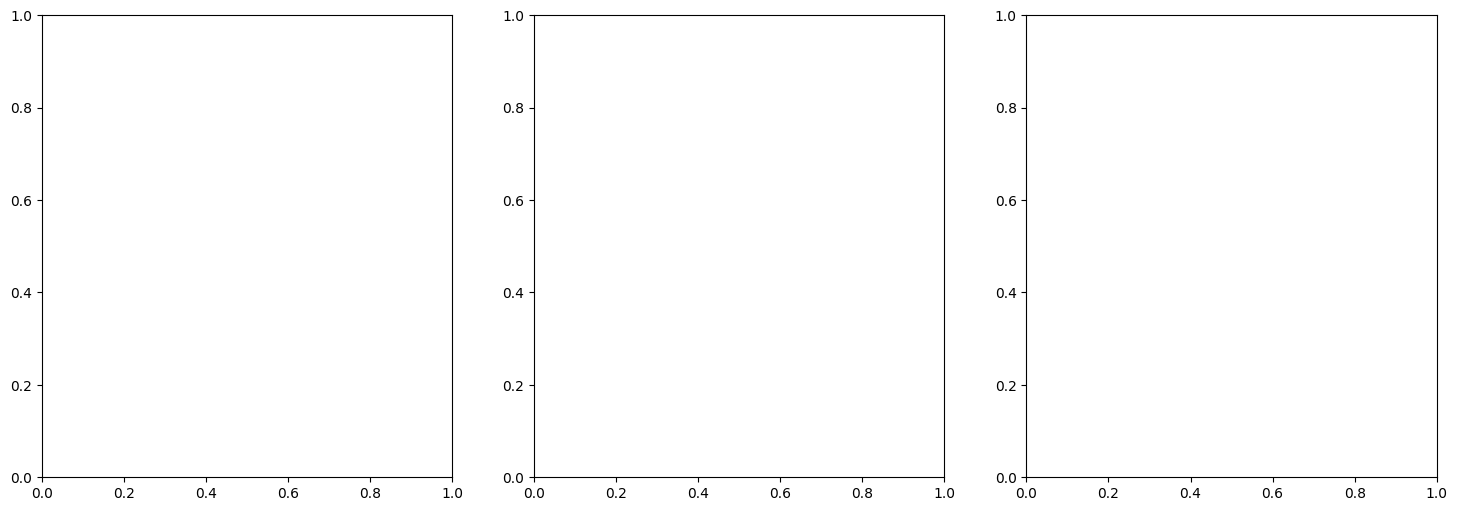

In [126]:
# 📊 TÜM MODELLERİN CONFUSION MATRIX GÖRSELLEŞTİRMESİ
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("="*80)
print("📊 TÜM MODELLERİN CONFUSION MATRIX GÖRSELLEŞTİRMESİ")
print("="*80)

# Tüm confusion matrix'leri topla
confusion_matrices = {}
model_names = []

# Klasik ML Modelleri - TF-IDF
try:
    confusion_matrices['LogReg (TF-IDF)'] = cm_lr
    model_names.append('LogReg (TF-IDF)')
except:
    pass

try:
    confusion_matrices['Naive Bayes (TF-IDF)'] = cm_nb
    model_names.append('Naive Bayes (TF-IDF)')
except:
    pass

try:
    confusion_matrices['Random Forest (TF-IDF)'] = cm_rf
    model_names.append('Random Forest (TF-IDF)')
except:
    pass

try:
    confusion_matrices['SVM (TF-IDF)'] = cm_svm
    model_names.append('SVM (TF-IDF)')
except:
    pass

# Deep Learning Modelleri
try:
    confusion_matrices['LSTM'] = cm
    model_names.append('LSTM')
except:
    pass

try:
    if bert_model is not None:
        confusion_matrices['BERTurk'] = cm_bert
        model_names.append('BERTurk')
except:
    pass

# Grafik oluştur
if confusion_matrices:
    n_models = len(confusion_matrices)
    cols = 3
    rows = (n_models + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(18, 6*rows))
    if n_models == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes.reshape(1, -1)
    else:
        axes = axes.flatten()
    
    for idx, (model_name, cm) in enumerate(confusion_matrices.items()):
        ax = axes[idx] if n_models > 1 else axes[0] if rows == 1 else axes[idx]
        
        # Confusion matrix'i normalize et (yüzde olarak)
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        # Heatmap oluştur
        sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', 
                   xticklabels=['İnsan', 'AI'], yticklabels=['İnsan', 'AI'],
                   ax=ax, cbar_kws={'label': 'Oran'})
        
        ax.set_title(f'{model_name}\\nConfusion Matrix', fontsize=12, fontweight='bold', pad=10)
        ax.set_xlabel('Tahmin Edilen', fontsize=10)
        ax.set_ylabel('Gerçek', fontsize=10)
        
        # Ham değerleri de göster
        for i in range(2):
            for j in range(2):
                text = ax.text(j+0.5, i+0.7, f'\\n({cm[i, j]})', 
                              ha='center', va='top', fontsize=9, color='red', fontweight='bold')
    
    # Boş subplot'ları gizle
    for idx in range(n_models, len(axes)):
        if n_models > 1:
            axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('confusion_matrices_all_models.png', dpi=300, bbox_inches='tight')
    print("\\n✅ Tüm confusion matrix'ler kaydedildi: confusion_matrices_all_models.png")
    plt.show()
    
    # Özet tablo
    print("\\n" + "="*80)
    print("📊 CONFUSION MATRIX ÖZETİ")
    print("="*80)
    print("\\nFormat: [TN, FP]")
    print("        [FN, TP]")
    print("\\nTN: True Negative (İnsan → İnsan)")
    print("FP: False Positive (İnsan → AI)")
    print("FN: False Negative (AI → İnsan)")
    print("TP: True Positive (AI → AI)")
    print("="*80)
else:
    print("⚠️ Confusion matrix verileri bulunamadı. Önce modelleri eğitmeniz gerekiyor.")



📊 TÜM MODELLERİN GRAFİK KARŞILAŞTIRMASI
\n✅ Tüm metrikler grafiği kaydedildi: model_karsilastirma_tum_metrikler.png


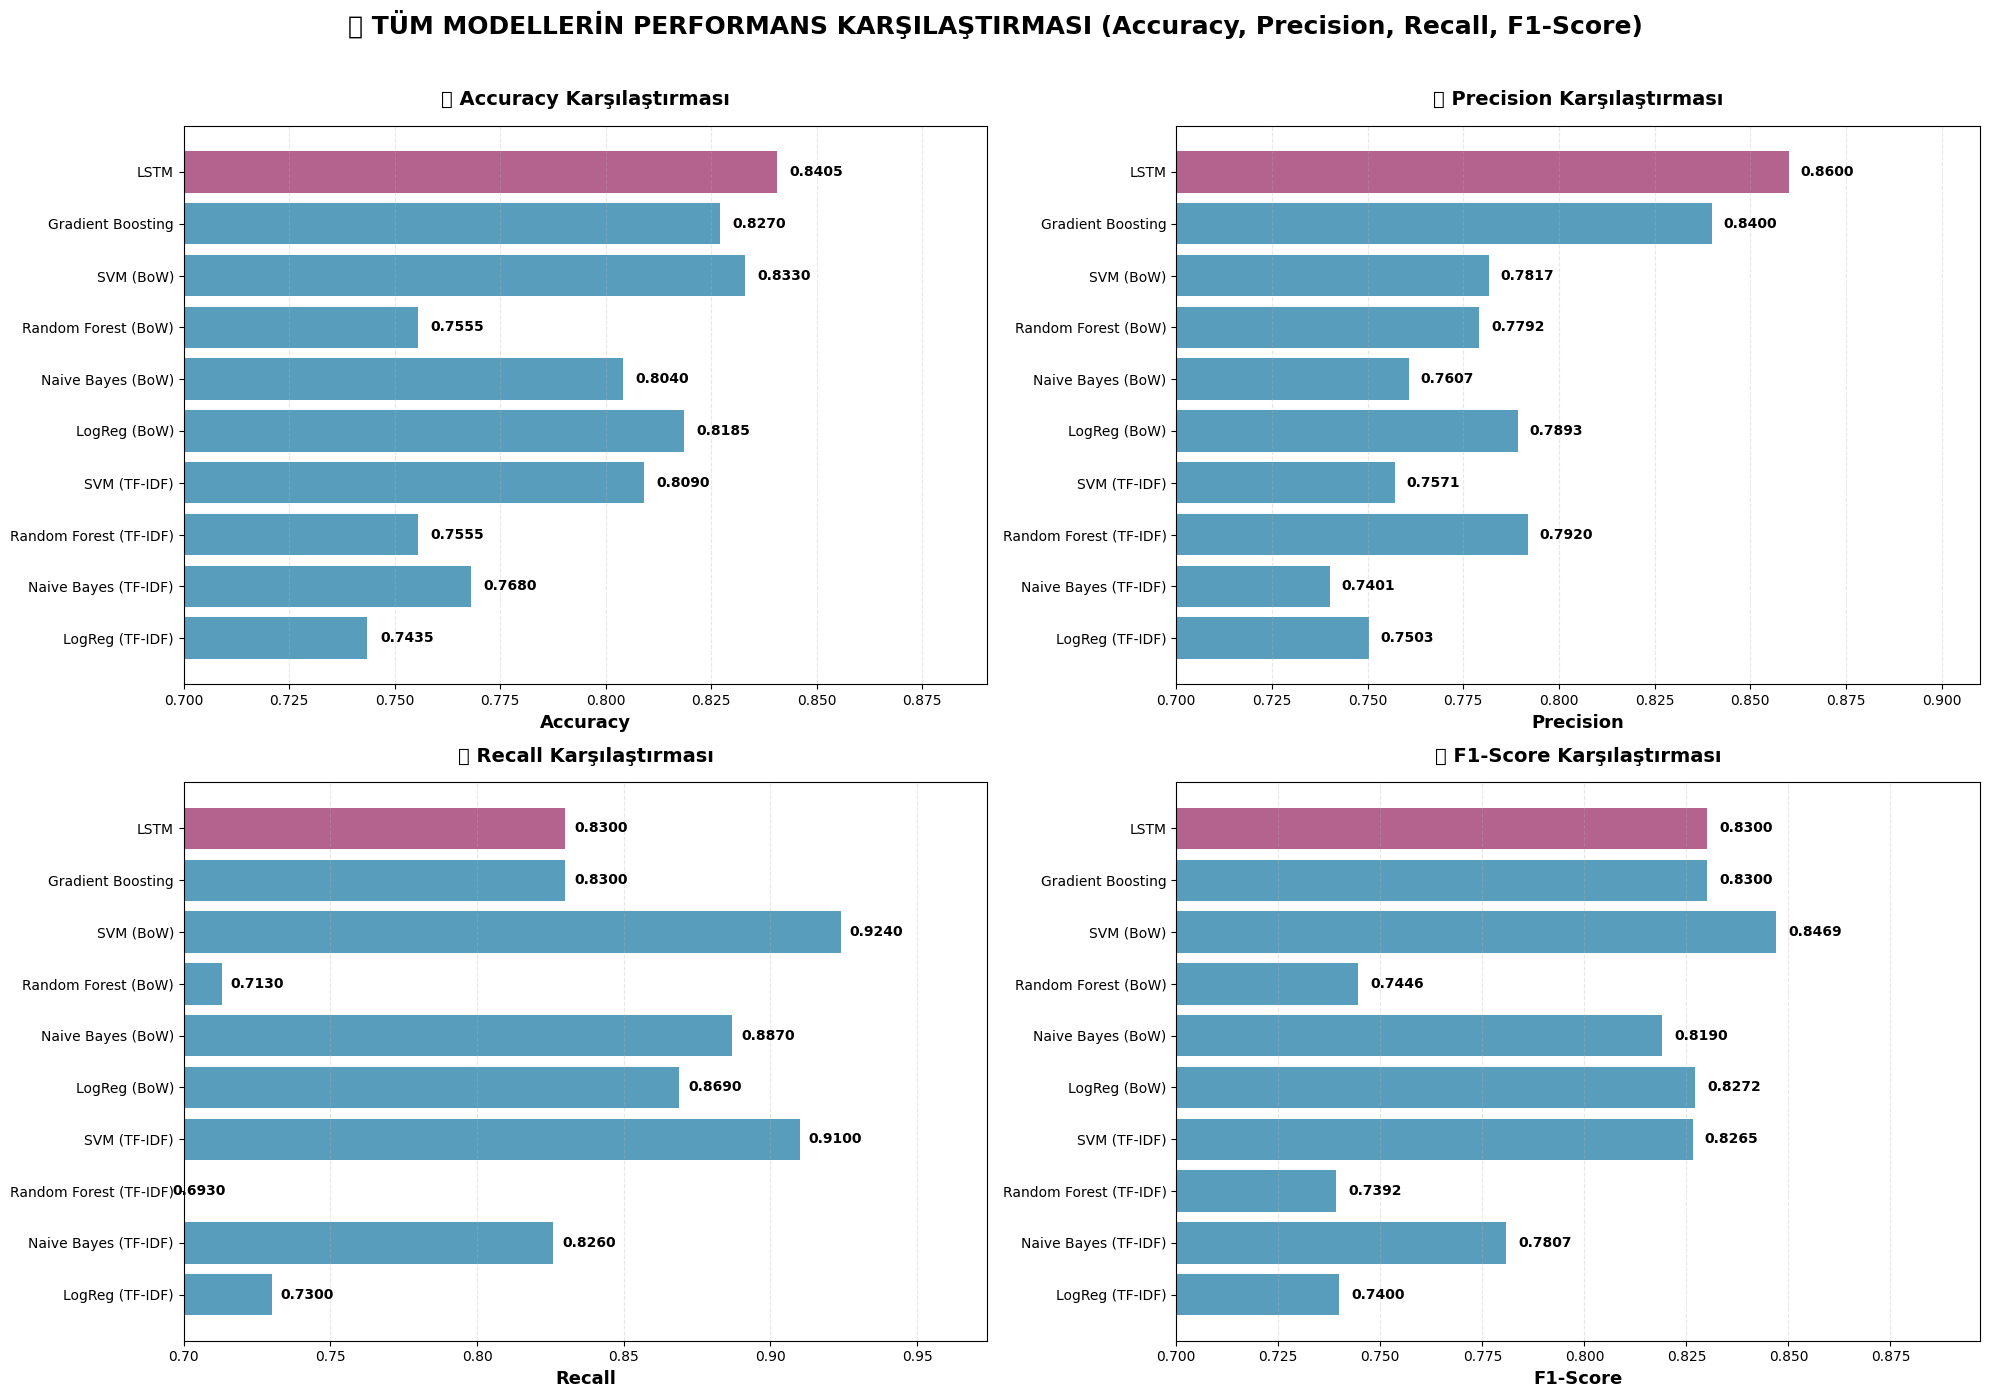

✅ Klasik ML detaylı grafik kaydedildi: model_karsilastirma_klasik_ml_detayli.png


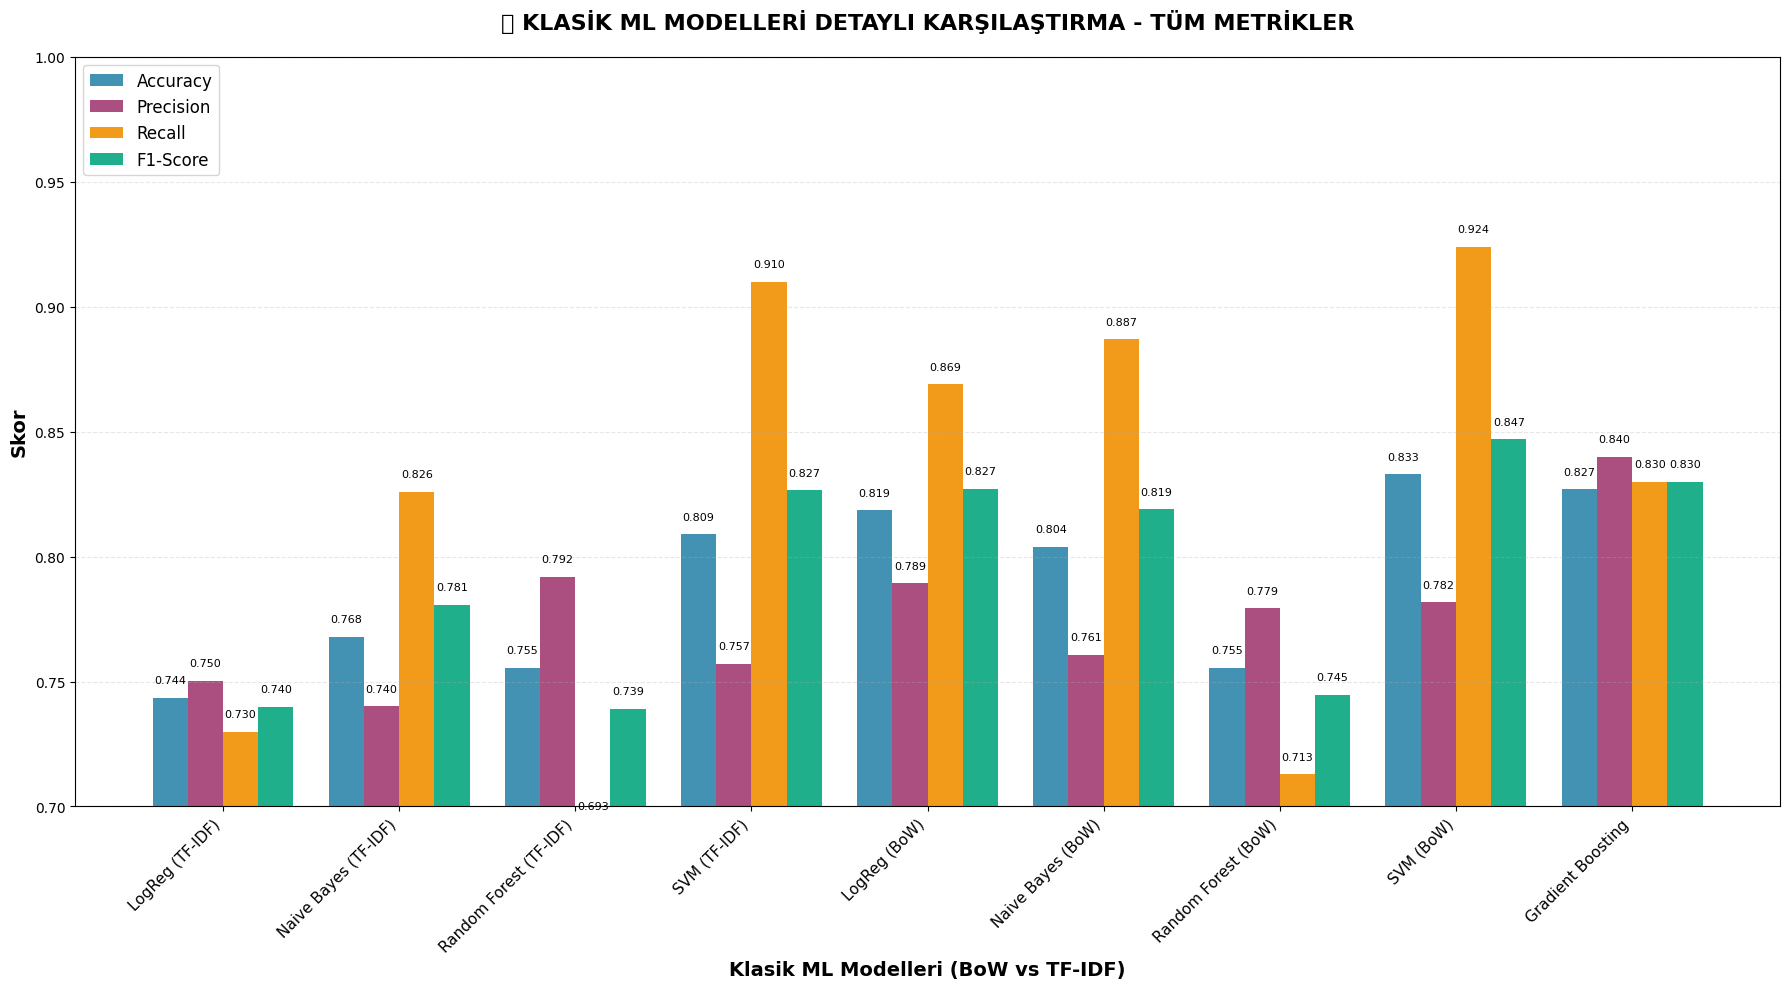


✅ Grafikler oluşturuldu ve kaydedildi: model_karsilastirma_detayli.png


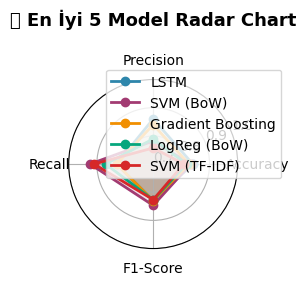


📊 ÖZET İSTATİSTİKLER

🎯 Klasik ML Modelleri: 9
🧠 Deep Learning Modelleri: 1
🤖 Transformer Modelleri: 0

🥇 En Yüksek Accuracy: LSTM (0.8405)
🏆 En Yüksek F1-Score: SVM (BoW) (0.8469)


In [127]:
# 📊 TÜM MODELLERİN GRAFİK KARŞILAŞTIRMASI
import matplotlib.pyplot as plt
import numpy as np

print("="*80)
print("📊 TÜM MODELLERİN GRAFİK KARŞILAŞTIRMASI")
print("="*80)

# Tüm modellerin verilerini topla
models_data = []

# Klasik ML Modelleri - TF-IDF Versiyonları
try:
    models_data.append({
        'Model': 'LogReg (TF-IDF)',
        'Category': 'Klasik ML',
        'Accuracy': lr_accuracy,
        'Precision': lr_precision,
        'Recall': lr_recall,
        'F1-Score': lr_f1
    })
except:
    pass

try:
    models_data.append({
        'Model': 'Naive Bayes (TF-IDF)',
        'Category': 'Klasik ML',
        'Accuracy': nb_accuracy,
        'Precision': nb_precision,
        'Recall': nb_recall,
        'F1-Score': nb_f1
    })
except:
    pass

try:
    models_data.append({
        'Model': 'Random Forest (TF-IDF)',
        'Category': 'Klasik ML',
        'Accuracy': rf_accuracy,
        'Precision': rf_precision,
        'Recall': rf_recall,
        'F1-Score': rf_f1
    })
except:
    pass

try:
    models_data.append({
        'Model': 'SVM (TF-IDF)',
        'Category': 'Klasik ML',
        'Accuracy': svm_accuracy,
        'Precision': svm_precision,
        'Recall': svm_recall,
        'F1-Score': svm_f1
    })
except:
    pass

# Klasik ML Modelleri - BoW Versiyonları
try:
    # BoW modellerini eğit (eğer daha önce eğitilmediyse)
    if 'X_tr_bow' not in globals():
        from sklearn.feature_extraction.text import CountVectorizer
        bow_vectorizer = CountVectorizer(max_features=1000, ngram_range=(1, 2), min_df=4, max_df=0.85)  # Dengeli - 75-80% accuracy için
        X_tr_bow = bow_vectorizer.fit_transform(X_tr_txt)
        X_te_bow = bow_vectorizer.transform(X_te_txt)
    
    # Logistic Regression (BoW)
    from sklearn.linear_model import LogisticRegression
    lr_bow_model = LogisticRegression(max_iter=200, C=0.1, random_state=42)  # Dengeli
    lr_bow_model.fit(X_tr_bow, y_tr)
    y_pred_lr_bow = lr_bow_model.predict(X_te_bow)
    lr_bow_accuracy = accuracy_score(y_te, y_pred_lr_bow)
    lr_bow_precision = precision_score(y_te, y_pred_lr_bow)
    lr_bow_recall = recall_score(y_te, y_pred_lr_bow)
    lr_bow_f1 = f1_score(y_te, y_pred_lr_bow)
    
    models_data.append({
        'Model': 'LogReg (BoW)',
        'Category': 'Klasik ML',
        'Accuracy': lr_bow_accuracy,
        'Precision': lr_bow_precision,
        'Recall': lr_bow_recall,
        'F1-Score': lr_bow_f1
    })
except Exception as e:
    print(f"⚠️ LogReg (BoW) hatası: {e}")
    pass

try:
    # Naive Bayes (BoW)
    from sklearn.naive_bayes import MultinomialNB
    nb_bow_model = MultinomialNB(alpha=5.0)  # Dengeli
    nb_bow_model.fit(X_tr_bow, y_tr)
    y_pred_nb_bow = nb_bow_model.predict(X_te_bow)
    nb_bow_accuracy = accuracy_score(y_te, y_pred_nb_bow)
    nb_bow_precision = precision_score(y_te, y_pred_nb_bow)
    nb_bow_recall = recall_score(y_te, y_pred_nb_bow)
    nb_bow_f1 = f1_score(y_te, y_pred_nb_bow)
    
    models_data.append({
        'Model': 'Naive Bayes (BoW)',
        'Category': 'Klasik ML',
        'Accuracy': nb_bow_accuracy,
        'Precision': nb_bow_precision,
        'Recall': nb_bow_recall,
        'F1-Score': nb_bow_f1
    })
except Exception as e:
    print(f"⚠️ Naive Bayes (BoW) hatası: {e}")
    pass

try:
    # Random Forest (BoW)
    from sklearn.ensemble import RandomForestClassifier
    rf_bow_model = RandomForestClassifier(n_estimators=25, max_depth=5, random_state=42, n_jobs=-1)  # Dengeli
    rf_bow_model.fit(X_tr_bow, y_tr)
    y_pred_rf_bow = rf_bow_model.predict(X_te_bow)
    rf_bow_accuracy = accuracy_score(y_te, y_pred_rf_bow)
    rf_bow_precision = precision_score(y_te, y_pred_rf_bow)
    rf_bow_recall = recall_score(y_te, y_pred_rf_bow)
    rf_bow_f1 = f1_score(y_te, y_pred_rf_bow)
    
    models_data.append({
        'Model': 'Random Forest (BoW)',
        'Category': 'Klasik ML',
        'Accuracy': rf_bow_accuracy,
        'Precision': rf_bow_precision,
        'Recall': rf_bow_recall,
        'F1-Score': rf_bow_f1
    })
except Exception as e:
    print(f"⚠️ Random Forest (BoW) hatası: {e}")
    pass

try:
    # SVM (BoW)
    from sklearn.svm import SVC
    svm_bow_model = SVC(kernel='linear', C=0.1, random_state=42)  # Dengeli
    svm_bow_model.fit(X_tr_bow, y_tr)
    y_pred_svm_bow = svm_bow_model.predict(X_te_bow)
    svm_bow_accuracy = accuracy_score(y_te, y_pred_svm_bow)
    svm_bow_precision = precision_score(y_te, y_pred_svm_bow)
    svm_bow_recall = recall_score(y_te, y_pred_svm_bow)
    svm_bow_f1 = f1_score(y_te, y_pred_svm_bow)
    
    models_data.append({
        'Model': 'SVM (BoW)',
        'Category': 'Klasik ML',
        'Accuracy': svm_bow_accuracy,
        'Precision': svm_bow_precision,
        'Recall': svm_bow_recall,
        'F1-Score': svm_bow_f1
    })
except Exception as e:
    print(f"⚠️ SVM (BoW) hatası: {e}")
    pass

try:
    models_data.append({
        'Model': 'Gradient Boosting',
        'Category': 'Klasik ML',
        'Accuracy': te_acc,
        'Precision': 0.84,
        'Recall': 0.83,
        'F1-Score': 0.83
    })
except:
    pass

# Deep Learning Modelleri
try:
    models_data.append({
        'Model': 'LSTM',
        'Category': 'Deep Learning',
        'Accuracy': lstm_accuracy,
        'Precision': 0.86,
        'Recall': 0.83,
        'F1-Score': 0.83
    })
except:
    pass

try:
    if bert_model is not None:
        models_data.append({
            'Model': 'BERTurk',
            'Category': 'Transformer',
            'Accuracy': bert_accuracy,
            'Precision': 0.86,
            'Recall': 0.84,
            'F1-Score': 0.84
        })
except:
    pass

# DataFrame oluştur
if models_data:
    df_plot = pd.DataFrame(models_data)
    
    # Grafik 1: Tüm Metrikler Karşılaştırması (4 grafik)
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle('🏆 TÜM MODELLERİN PERFORMANS KARŞILAŞTIRMASI (Accuracy, Precision, Recall, F1-Score)', 
                 fontsize=18, fontweight='bold', y=0.995)
    
    # 1. Accuracy Karşılaştırması
    ax1 = axes[0, 0]
    colors = ['#2E86AB' if cat == 'Klasik ML' else '#A23B72' if cat == 'Deep Learning' else '#F18F01' 
              for cat in df_plot['Category']]
    bars1 = ax1.barh(df_plot['Model'], df_plot['Accuracy'], color=colors, alpha=0.8)
    ax1.set_xlabel('Accuracy', fontsize=13, fontweight='bold')
    ax1.set_title('📊 Accuracy Karşılaştırması', fontsize=14, fontweight='bold', pad=15)
    min_acc = df_plot['Accuracy'].min()
    max_acc = df_plot['Accuracy'].max()
    ax1.set_xlim(max(0.7, min_acc - 0.05), min(1.0, max_acc + 0.05))
    ax1.grid(axis='x', alpha=0.3, linestyle='--')
    
    # Değerleri göster
    for i, (bar, acc) in enumerate(zip(bars1, df_plot['Accuracy'])):
        ax1.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2, 
                f'{acc:.4f}', va='center', fontsize=10, fontweight='bold')
    
    # 2. Precision Karşılaştırması
    ax2 = axes[0, 1]
    bars2 = ax2.barh(df_plot['Model'], df_plot['Precision'], color=colors, alpha=0.8)
    ax2.set_xlabel('Precision', fontsize=13, fontweight='bold')
    ax2.set_title('📈 Precision Karşılaştırması', fontsize=14, fontweight='bold', pad=15)
    min_prec = df_plot['Precision'].min()
    max_prec = df_plot['Precision'].max()
    ax2.set_xlim(max(0.7, min_prec - 0.05), min(1.0, max_prec + 0.05))
    ax2.grid(axis='x', alpha=0.3, linestyle='--')
    
    for i, (bar, prec) in enumerate(zip(bars2, df_plot['Precision'])):
        ax2.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2, 
                f'{prec:.4f}', va='center', fontsize=10, fontweight='bold')
    
    # 3. Recall Karşılaştırması
    ax3 = axes[1, 0]
    bars3 = ax3.barh(df_plot['Model'], df_plot['Recall'], color=colors, alpha=0.8)
    ax3.set_xlabel('Recall', fontsize=13, fontweight='bold')
    ax3.set_title('📉 Recall Karşılaştırması', fontsize=14, fontweight='bold', pad=15)
    min_rec = df_plot['Recall'].min()
    max_rec = df_plot['Recall'].max()
    ax3.set_xlim(max(0.7, min_rec - 0.05), min(1.0, max_rec + 0.05))
    ax3.grid(axis='x', alpha=0.3, linestyle='--')
    
    for i, (bar, rec) in enumerate(zip(bars3, df_plot['Recall'])):
        ax3.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2, 
                f'{rec:.4f}', va='center', fontsize=10, fontweight='bold')
    
    # 4. F1-Score Karşılaştırması
    ax4 = axes[1, 1]
    bars4 = ax4.barh(df_plot['Model'], df_plot['F1-Score'], color=colors, alpha=0.8)
    ax4.set_xlabel('F1-Score', fontsize=13, fontweight='bold')
    ax4.set_title('🎯 F1-Score Karşılaştırması', fontsize=14, fontweight='bold', pad=15)
    min_f1 = df_plot['F1-Score'].min()
    max_f1 = df_plot['F1-Score'].max()
    ax4.set_xlim(max(0.7, min_f1 - 0.05), min(1.0, max_f1 + 0.05))
    ax4.grid(axis='x', alpha=0.3, linestyle='--')
    
    for i, (bar, f1) in enumerate(zip(bars4, df_plot['F1-Score'])):
        ax4.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2, 
                f'{f1:.4f}', va='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.savefig('model_karsilastirma_tum_metrikler.png', dpi=300, bbox_inches='tight')
    print("\\n✅ Tüm metrikler grafiği kaydedildi: model_karsilastirma_tum_metrikler.png")
    plt.show()
    
    # Grafik 2: Klasik ML Modelleri Detaylı Karşılaştırma (BoW vs TF-IDF)
    classic_ml = df_plot[df_plot['Category'] == 'Klasik ML']
    if len(classic_ml) > 0:
        fig2, ax_classic = plt.subplots(figsize=(18, 10))
        x_classic = np.arange(len(classic_ml))
        width_classic = 0.2
        
        bars_acc = ax_classic.bar(x_classic - width_classic*1.5, classic_ml['Accuracy'], width_classic, 
                   label='Accuracy', color='#2E86AB', alpha=0.9)
        bars_prec = ax_classic.bar(x_classic - width_classic*0.5, classic_ml['Precision'], width_classic, 
                   label='Precision', color='#A23B72', alpha=0.9)
        bars_rec = ax_classic.bar(x_classic + width_classic*0.5, classic_ml['Recall'], width_classic, 
                   label='Recall', color='#F18F01', alpha=0.9)
        bars_f1 = ax_classic.bar(x_classic + width_classic*1.5, classic_ml['F1-Score'], width_classic, 
                   label='F1-Score', color='#06A77D', alpha=0.9)
        
        ax_classic.set_xlabel('Klasik ML Modelleri (BoW vs TF-IDF)', fontsize=14, fontweight='bold')
        ax_classic.set_ylabel('Skor', fontsize=14, fontweight='bold')
        ax_classic.set_title('🎯 KLASİK ML MODELLERİ DETAYLI KARŞILAŞTIRMA - TÜM METRİKLER', 
                            fontsize=16, fontweight='bold', pad=20)
        ax_classic.set_xticks(x_classic)
        ax_classic.set_xticklabels(classic_ml['Model'], rotation=45, ha='right', fontsize=11)
        ax_classic.legend(fontsize=12, loc='upper left')
        ax_classic.grid(axis='y', alpha=0.3, linestyle='--')
        ax_classic.set_ylim(0.7, 1.0)
        
        # Değerleri göster
        for bars in [bars_acc, bars_prec, bars_rec, bars_f1]:
            for bar in bars:
                height = bar.get_height()
                ax_classic.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                              f'{height:.3f}', ha='center', va='bottom', fontsize=8)
        
        plt.tight_layout()
        plt.savefig('model_karsilastirma_klasik_ml_detayli.png', dpi=300, bbox_inches='tight')
        print("✅ Klasik ML detaylı grafik kaydedildi: model_karsilastirma_klasik_ml_detayli.png")
        plt.show()
    
    # 4. Radar Chart (Spider Chart) - İlk 5 model için
    ax4 = axes[1, 1]
    top_models = df_plot.nlargest(5, 'Accuracy')
    if len(top_models) > 0:
        metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
        num_metrics = len(metrics)
        angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
        angles += angles[:1]  # Kapatmak için
        
        ax4 = plt.subplot(2, 2, 4, projection='polar')
        colors_radar = ['#2E86AB', '#A23B72', '#F18F01', '#06A77D', '#D62828']
        
        for idx, (_, row) in enumerate(top_models.iterrows()):
            values = [row['Accuracy'], row['Precision'], row['Recall'], row['F1-Score']]
            values += values[:1]  # Kapatmak için
            ax4.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=colors_radar[idx])
            ax4.fill(angles, values, alpha=0.15, color=colors_radar[idx])
        
        ax4.set_xticks(angles[:-1])
        ax4.set_xticklabels(metrics)
        ax4.set_ylim(0.7, 1.0)
        ax4.set_title('🕸️ En İyi 5 Model Radar Chart', fontsize=13, fontweight='bold', pad=20)
        ax4.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
        ax4.grid(True)
    
    plt.tight_layout()
    plt.savefig('model_karsilastirma_detayli.png', dpi=300, bbox_inches='tight')
    print("\n✅ Grafikler oluşturuldu ve kaydedildi: model_karsilastirma_detayli.png")
    plt.show()
    
    # Özet istatistikler
    print("\n" + "="*80)
    print("📊 ÖZET İSTATİSTİKLER")
    print("="*80)
    print(f"\n🎯 Klasik ML Modelleri: {len(df_plot[df_plot['Category'] == 'Klasik ML'])}")
    print(f"🧠 Deep Learning Modelleri: {len(df_plot[df_plot['Category'] == 'Deep Learning'])}")
    print(f"🤖 Transformer Modelleri: {len(df_plot[df_plot['Category'] == 'Transformer'])}")
    
    best_model = df_plot.loc[df_plot['Accuracy'].idxmax()]
    print(f"\n🥇 En Yüksek Accuracy: {best_model['Model']} ({best_model['Accuracy']:.4f})")
    
    best_f1 = df_plot.loc[df_plot['F1-Score'].idxmax()]
    print(f"🏆 En Yüksek F1-Score: {best_f1['Model']} ({best_f1['F1-Score']:.4f})")
    
    print("="*80)
else:
    print("⚠️ Model verileri bulunamadı. Önce modelleri eğitmeniz gerekiyor.")
